<a href="https://www.kaggle.com/code/pbarrmo/personal-loan-prediction?scriptVersionId=217458694" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Data Analysis and Model Building for Personal Loan Prediction

This notebook provides a detailed analysis of data from AllLife Bank to identify customers with a higher likelihood of accepting personal loans. It includes data exploration, predictive model construction, and actionable insights.

## Background

- AllLife Bank is a U.S.-based bank with a growing customer base.
- The bank aims to expand its personal loan business among its depositors.
- The previous campaign achieved a conversion rate of over 9%.

## Main Objective

- Build a model to help the marketing department identify customers with a high likelihood of purchasing a personal loan.


## Procedures

1. Explore and summarize the data (EDA).
2. Preprocess the data.
3. Build predictive models.
4. Evaluate model performance.
5. Analyze misclassification and metrics.
6. Provide actionable insights and conclusions.


## Dataset Description

- **ID**: Unique customer identifier.
- **Age**: Customer's age (in years).
- **Experience**: Years of professional experience.
- **Income**: Annual income of the customer (in thousands of dollars).
- **ZIP Code**: Customer's home address ZIP code.
- **Family**: Size of the customer's family.
- **CCAvg**: Average monthly spending on credit cards (in thousands of dollars).
- **Education**: Education level of the customer:
  - 1: Undergraduate
  - 2: Graduate
  - 3: Advanced/Professional
- **Mortgage**: Value of the customer's house mortgage (if any, in thousands of dollars).
- **Personal_Loan**: Whether the customer accepted the personal loan offered in the last campaign.
- **Securities_Account**: Whether the customer has a securities account with the bank.
- **CD_Account**: Whether the customer has a certificate of deposit (CD) account with the bank.
- **Online**: Whether the customer uses internet banking services.
- **CreditCard**: Whether the customer uses a credit card issued by another bank.


## Exploratory Data Analysis (EDA)

### Univariate Analysis
- The average age is 45 years.
- The average income is $73k.
- Most families have one member (29%).

### Bivariate Analysis
- High correlation between age and experience.
- Customers who accepted loans had higher income (minimum 150k) and higher credit card spending (median 4k).


## General Observations

- The dataset has 5,000 records and 14 columns.
- No missing values are present.
- Most customers (90.4%) did not accept the personal loan.
- Negative values are present in the experience column (requires review).


## Model Conclusions

- The Decision Tree with post-pruning performed the best:
  - Recall: 0.92 on testing data.
  - Misclassification rate: 0.016.
- The most significant variables were: education level, income, and family size.


## Code

In [1]:
!pip install --upgrade pandas-profiling

In [2]:
!pip install pydantic==1.10.12

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.3/149.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 56.8 MB/s eta 0:00:00
  Attempting uninstall: pydantic
    Found existing installation: pydantic 2.9.2
    Uninstalling pydantic-2.9.2:
      Successfully uninstalled pydantic-2.9.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
albumentations 1.4.15 requires pydantic>=2.7.0, but you have pydantic 1.10.12 which is incompatible.
google-genai 0.3.0 requires pydantic<3.0.0dev,>=2.0.0, but you have pydantic 1.10.12 which is incompatible.
wandb 0.19.1 requires pydantic<3,>=2.6, but you have pydantic 1.10.12 which is incompatible.
ydata-profiling 4.12.1 requires pydantic>=2, but you have pydantic 1.10.12 which is incompatible.


In [3]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Library to split data
from sklearn.model_selection import train_test_split

# Libraries to help with model building
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")

# To enable plotting graphs in Jupyter notebook
%matplotlib inline

# Removes the limit from the number of displayed columns and rows.
pd.set_option("display.max_columns", None)
# pd.set_option('display.max_rows', None)
pd.set_option("display.max_rows", 200)

# for statistical analysis 
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


# To get diferent metric scores
from sklearn import metrics
from sklearn.metrics import accuracy_score, recall_score, precision_score, roc_auc_score, roc_curve, confusion_matrix, precision_recall_curve
from sklearn.model_selection import GridSearchCV

# For pandas profiling
from pandas_profiling import ProfileReport

In [4]:
# Load the data into pandas dataframe
data = pd.read_csv('/kaggle/input/loan-modelling-csv/Loan_Modelling.csv')    

In [5]:
# Check the first lines
data.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [6]:
# Check number of rows and columns
data.shape

(5000, 14)

In [7]:
# Check columns names
data.columns

Index(['ID', 'Age', 'Experience', 'Income', 'ZIPCode', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account',
       'CD_Account', 'Online', 'CreditCard'],
      dtype='object')

In [8]:
# Check columns description
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [9]:
# Check the current data types 
data.dtypes

ID                      int64
Age                     int64
Experience              int64
Income                  int64
ZIPCode                 int64
Family                  int64
CCAvg                 float64
Education               int64
Mortgage                int64
Personal_Loan           int64
Securities_Account      int64
CD_Account              int64
Online                  int64
CreditCard              int64
dtype: object

In [10]:
# Check the unique value in each column of the dataframe
data.nunique()

ID                    5000
Age                     45
Experience              47
Income                 162
ZIPCode                467
Family                   4
CCAvg                  108
Education                3
Mortgage               347
Personal_Loan            2
Securities_Account       2
CD_Account               2
Online                   2
CreditCard               2
dtype: int64

In [11]:
# Check missing data
data.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64

- There are 14 columns and 5,000 rows in the dataset.  
- The personal loan is the dependent variable, indicating whether a customer accepted the personal loan offered in the last campaign.  
- Column names do not contain spaces or special characters, except for the serial number.  
- Family, Education, Personal_Loan, Securities_Account, CD_Account, Online, and CreditCard should be set as categorical variables.  
- There are 5,000 unique values in the ID column, as expected since it represents unique customers.  
- There is no missing data.  


### First Data Preprocessing

In [12]:
# Making Objects into Categorical Types
cat_vars = ['Family','Education','Personal_Loan','Securities_Account','CD_Account','Online','CreditCard']

for colname in cat_vars:
    data[colname] = data[colname].astype('category')
    
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   ID                  5000 non-null   int64   
 1   Age                 5000 non-null   int64   
 2   Experience          5000 non-null   int64   
 3   Income              5000 non-null   int64   
 4   ZIPCode             5000 non-null   int64   
 5   Family              5000 non-null   category
 6   CCAvg               5000 non-null   float64 
 7   Education           5000 non-null   category
 8   Mortgage            5000 non-null   int64   
 9   Personal_Loan       5000 non-null   category
 10  Securities_Account  5000 non-null   category
 11  CD_Account          5000 non-null   category
 12  Online              5000 non-null   category
 13  CreditCard          5000 non-null   category
dtypes: category(7), float64(1), int64(6)
memory usage: 308.7 KB


In [13]:
# Making a list of all categorical variables
cat_col = [
    "Family",
    "Education",
    "Personal_Loan",
    "Securities_Account",
    "CD_Account",
    "Online",
    "CreditCard"
]

# Printing number of count of each unique value in each column
for column in cat_col:
    print(data[column].value_counts())
    print("-" * 40)

Family
1    1472
2    1296
4    1222
3    1010
Name: count, dtype: int64
----------------------------------------
Education
1    2096
3    1501
2    1403
Name: count, dtype: int64
----------------------------------------
Personal_Loan
0    4520
1     480
Name: count, dtype: int64
----------------------------------------
Securities_Account
0    4478
1     522
Name: count, dtype: int64
----------------------------------------
CD_Account
0    4698
1     302
Name: count, dtype: int64
----------------------------------------
Online
1    2984
0    2016
Name: count, dtype: int64
----------------------------------------
CreditCard
0    3530
1    1470
Name: count, dtype: int64
----------------------------------------


- There are four types of families based on the number of members: 1,472 customers have just one family member (themselves), 1,296 have two family members, 1,010 have three, and 1,222 have four members.  
- There are three education levels: 2,096 customers are undergraduates, 1,403 are graduates, and 1,501 have advanced/professional education.  
- The data shows that 480 customers accepted the personal loan last year, while 4,520 did not.  
- There are 522 customers who have securities with the bank, while 4,478 do not.  
- There are 302 customers who have a certificate of deposit, while 4,698 do not.  
- There are 2,984 customers with internet banking facilities, while 2,016 do not.  
- There are 1,470 customers who use a credit card issued by another bank, while 3,530 do not.  


In [14]:
# Summary of the data
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,5000.0,NaN,NaN,NaN,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,NaN,NaN,NaN,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,NaN,NaN,NaN,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,NaN,NaN,NaN,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,NaN,NaN,NaN,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,4.0,1.0,1472.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CCAvg,5000.0,NaN,NaN,NaN,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,3.0,1.0,2096.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mortgage,5000.0,NaN,NaN,NaN,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,2.0,0.0,4520.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Observations

- The minimum age is 23, and the maximum age is 67, which seems reasonable.  
- The minimum years of experience (-3) seem odd, while the maximum of 43 years appears reasonable.  
- Income, CCAvg, and mortgage values seem reasonable.  


###  Data Visualization
#### Univariate analysis

In [15]:
# Univariate analysis for the numerical variables using boxplot and histogram
# Create a function that takes the numerical column as the input and plot the data in a boxplot and histogram
def histogram_boxplot(feature, figsize=(15, 10), bins=None):
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        feature, ax=ax_box2, showmeans=True, color="#FFFF00"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.distplot(
        feature, kde=F, ax=ax_hist2, bins=bins, color="red"
    ) if bins else sns.distplot(
        feature, kde=False, ax=ax_hist2, color="aqua"
    )  # For histogram
    ax_hist2.axvline(
        np.mean(feature), color="blue", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        np.median(feature), color="black", linestyle="-"
    )  # Add median to the histogram

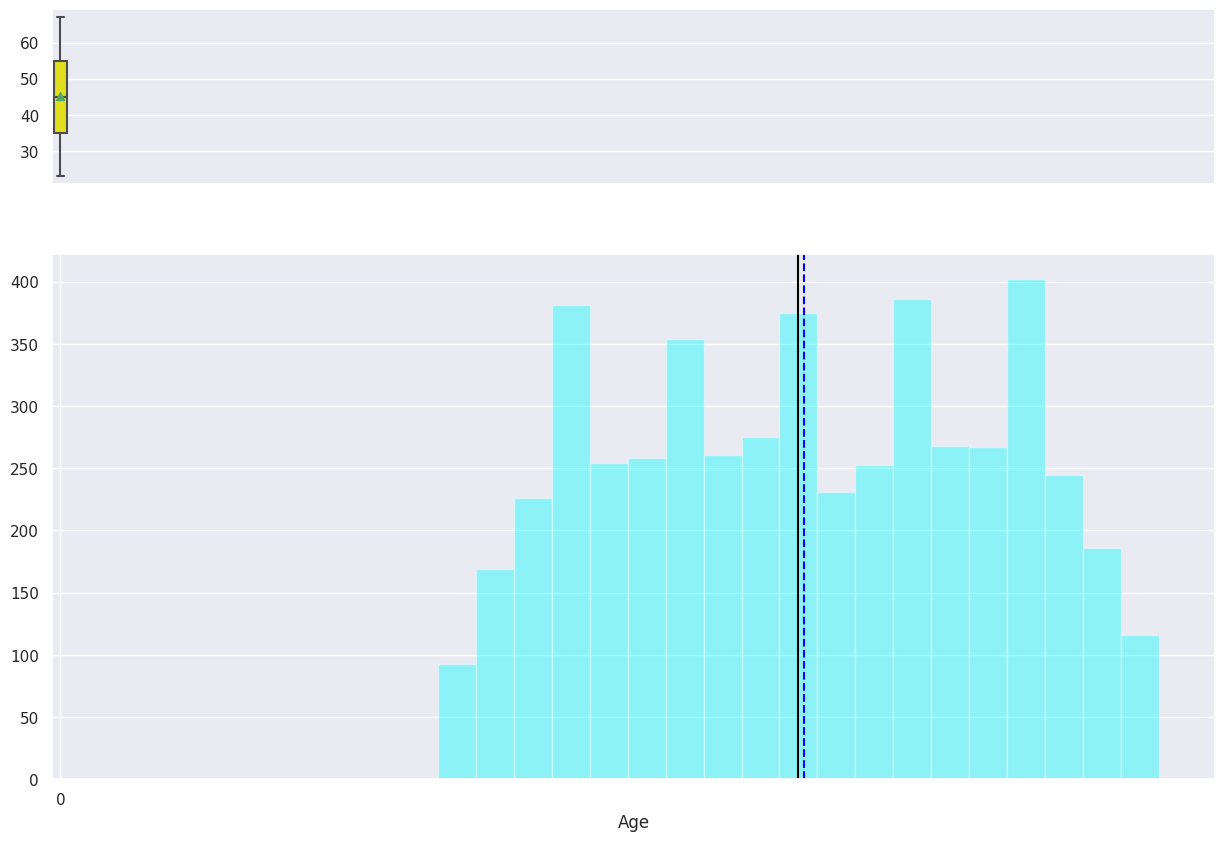

In [16]:
# Observation on Age
histogram_boxplot(data["Age"])


    There are no outliers.
    The average age is 45 years old.

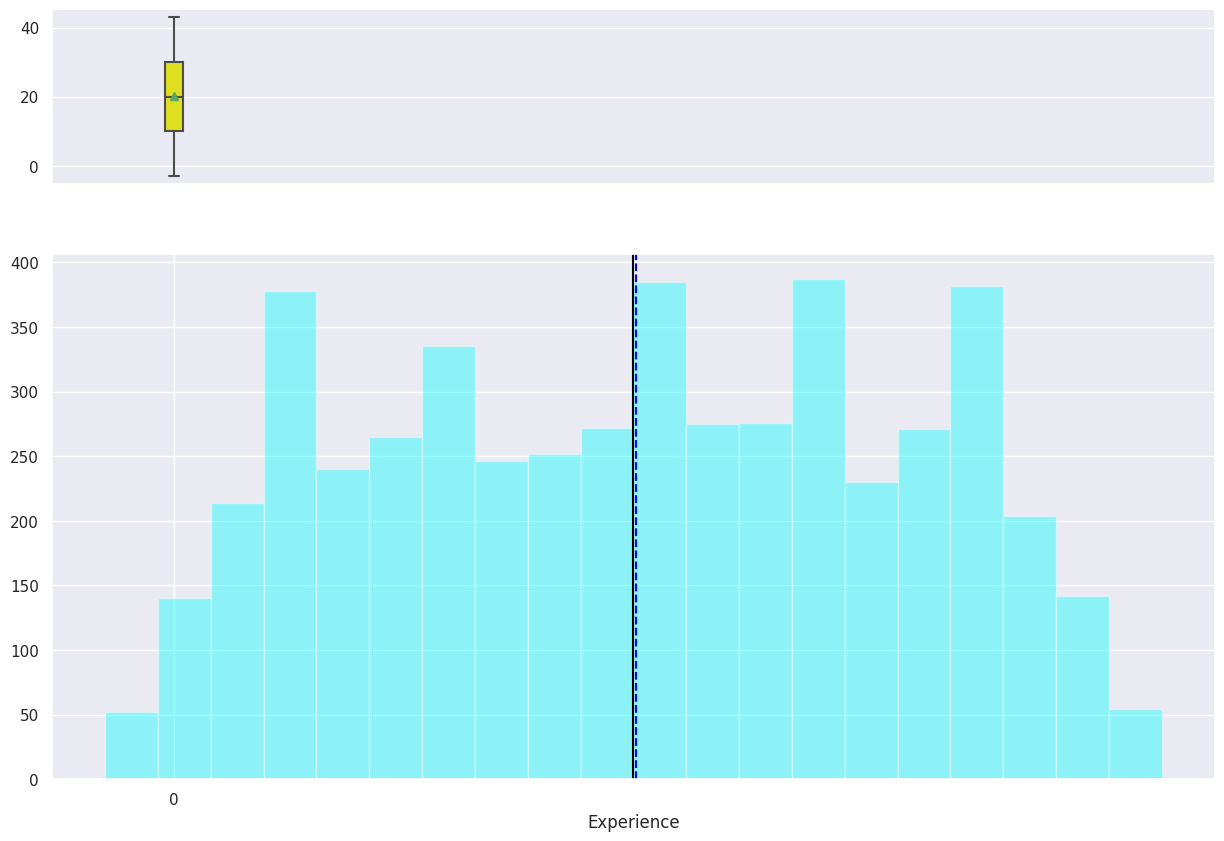

In [17]:
# Observation on Experience
histogram_boxplot(data["Experience"])


    There are no outliers.
    The average experience is 20 years.

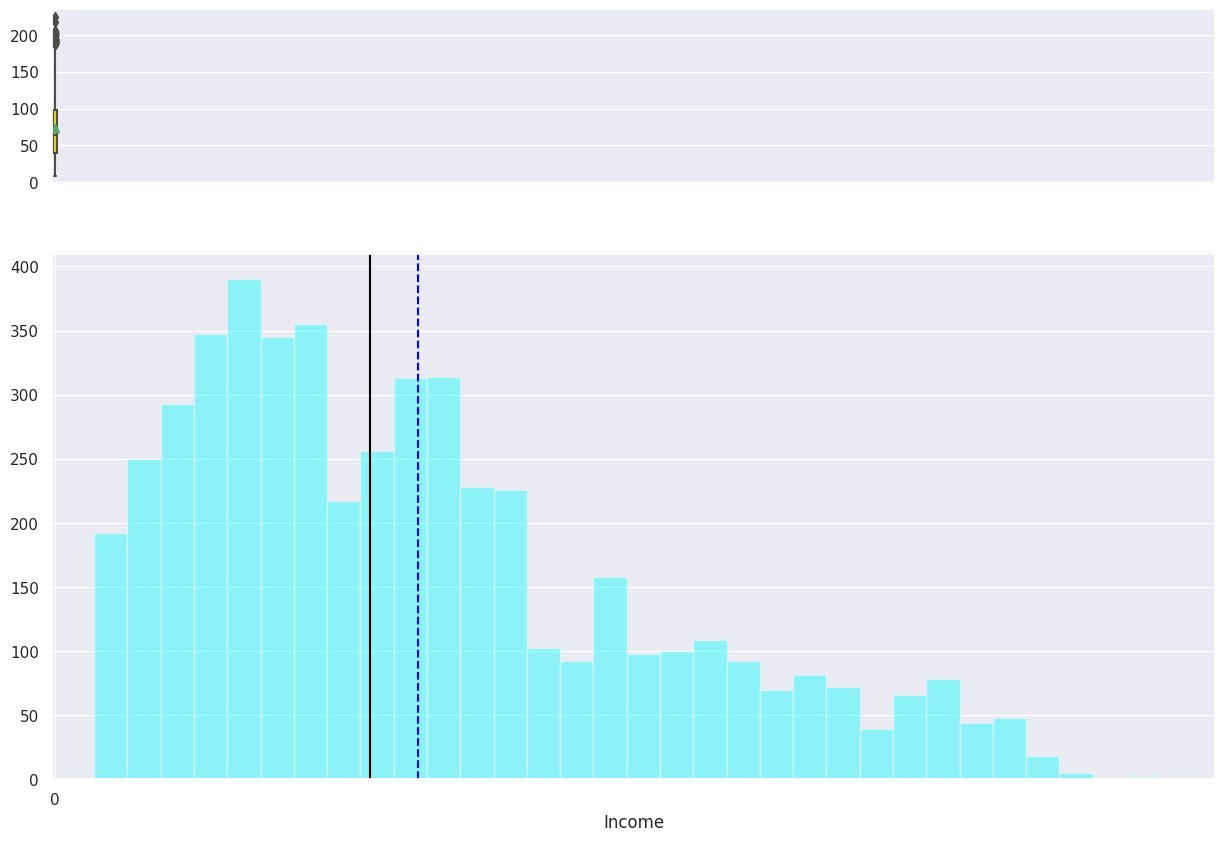

In [18]:
# Observation on Income
histogram_boxplot(data["Income"])


    The distrtibution of income is right-skewed.
    There are outliers in this variable.
    The average income is 73k.



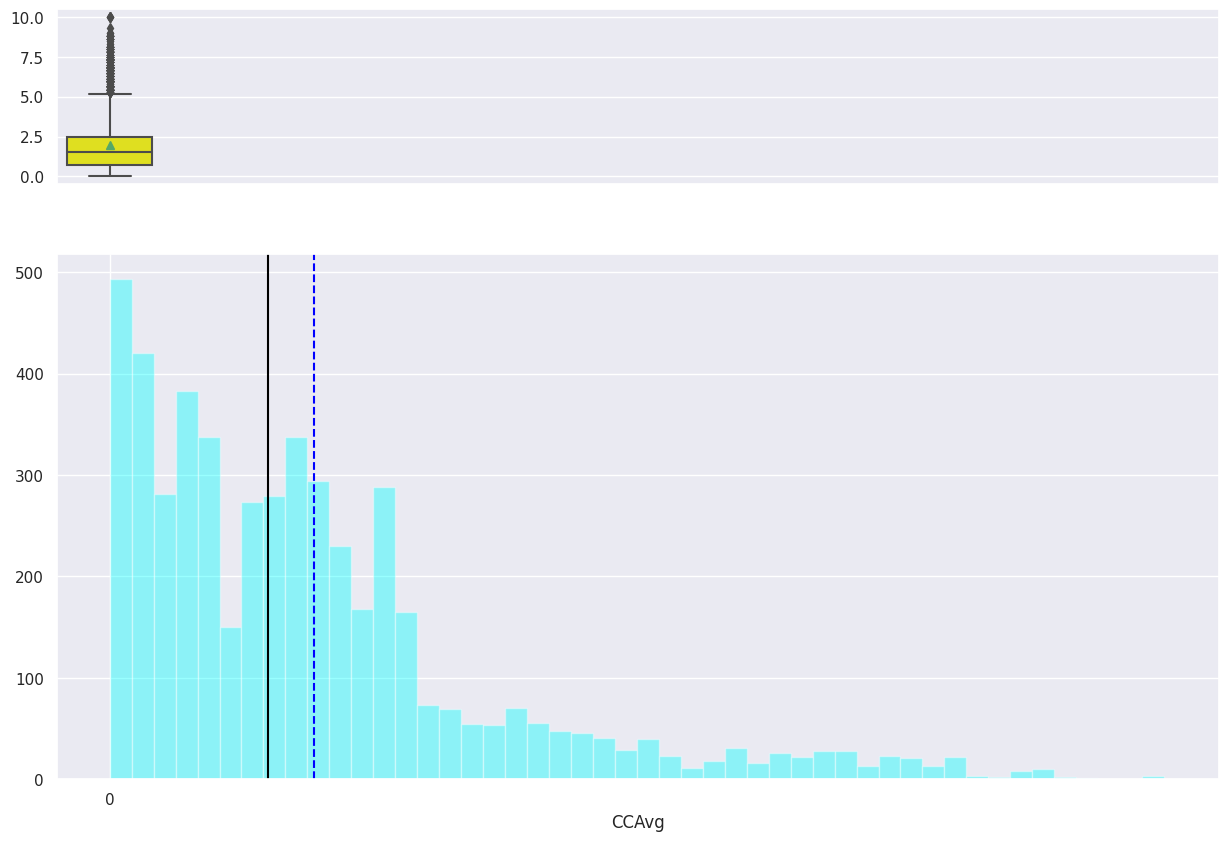

In [19]:
# Observation on CCAvg
histogram_boxplot(data["CCAvg"])


    The distrtibution is right-skewed.
    There are outliers in this variable.
    The average spending on credit cards per month is around 1.94k.



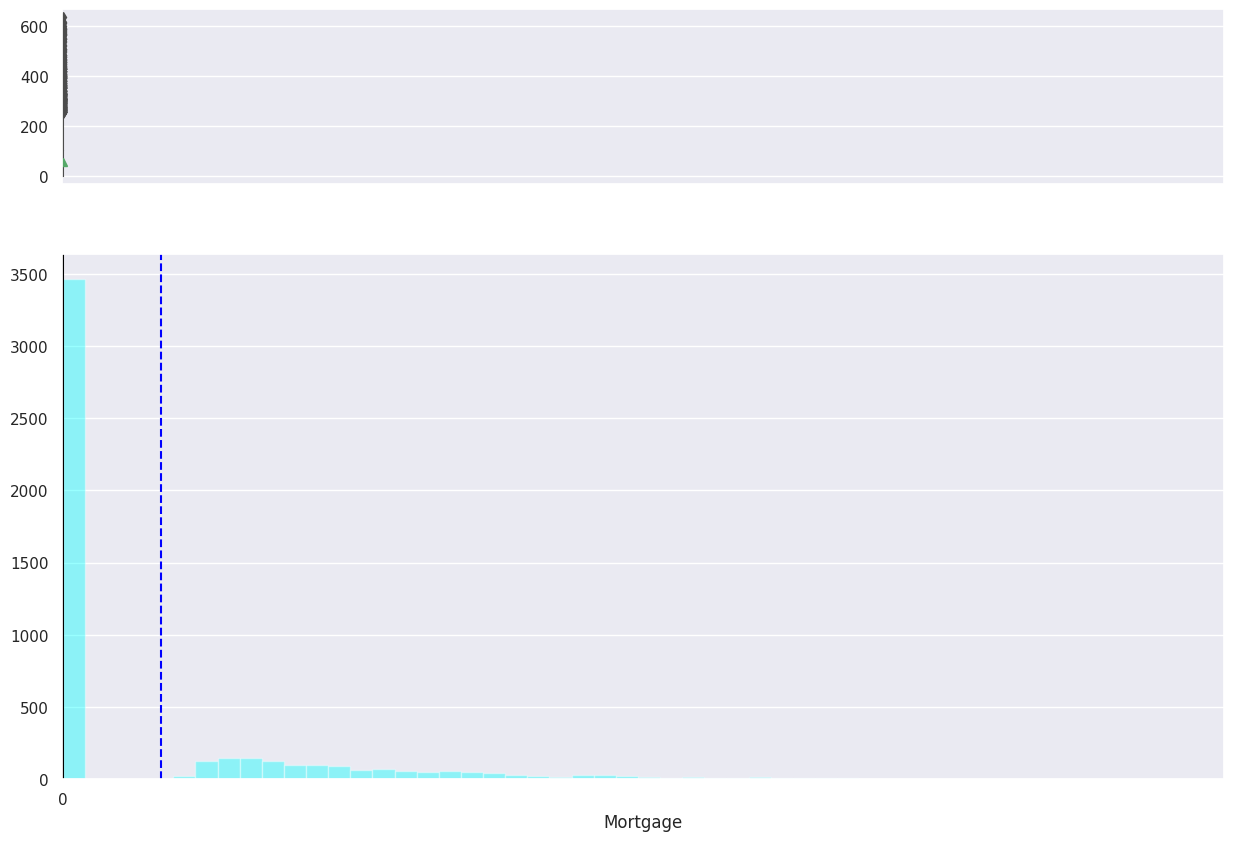

In [20]:
# Observation on Mortgage
histogram_boxplot(data["Mortgage"])


    The distrtibution is right-skewed.
    There are outliers in this variable.
    The average value of house mortgage is around 56k.



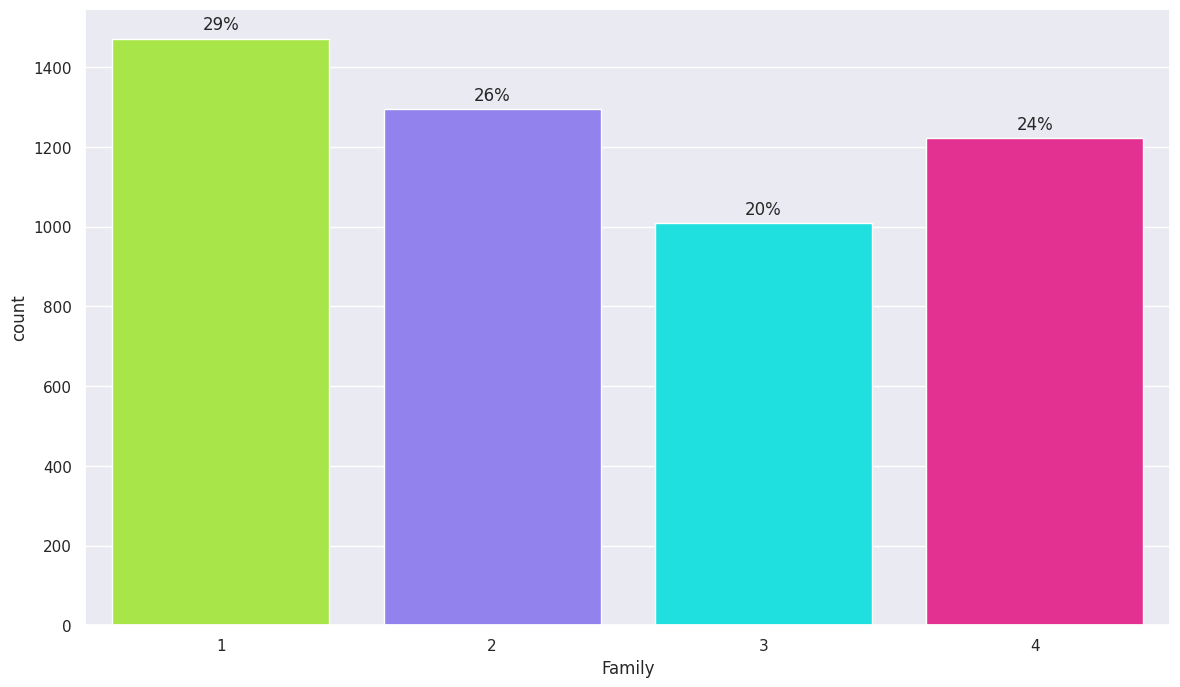

In [21]:
# Visualize categories 
plt.figure(figsize=(14,8))
total = len(data['Family'])*1
qualitative_colors = ["#ADFF2F","#8470FF","#00FFFF","#FF1493"]
splot= sns.countplot(data=data, x='Family', palette=qualitative_colors)


for p in splot.patches:
    splot.annotate('{:.0f}%'.format(100*p.get_height()/total),
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va='center', xytext = (0,10), textcoords = 'offset points')
plt.show()

29% of customers have just one member,
26% have two members,
20% have three members, and
24% have four members.

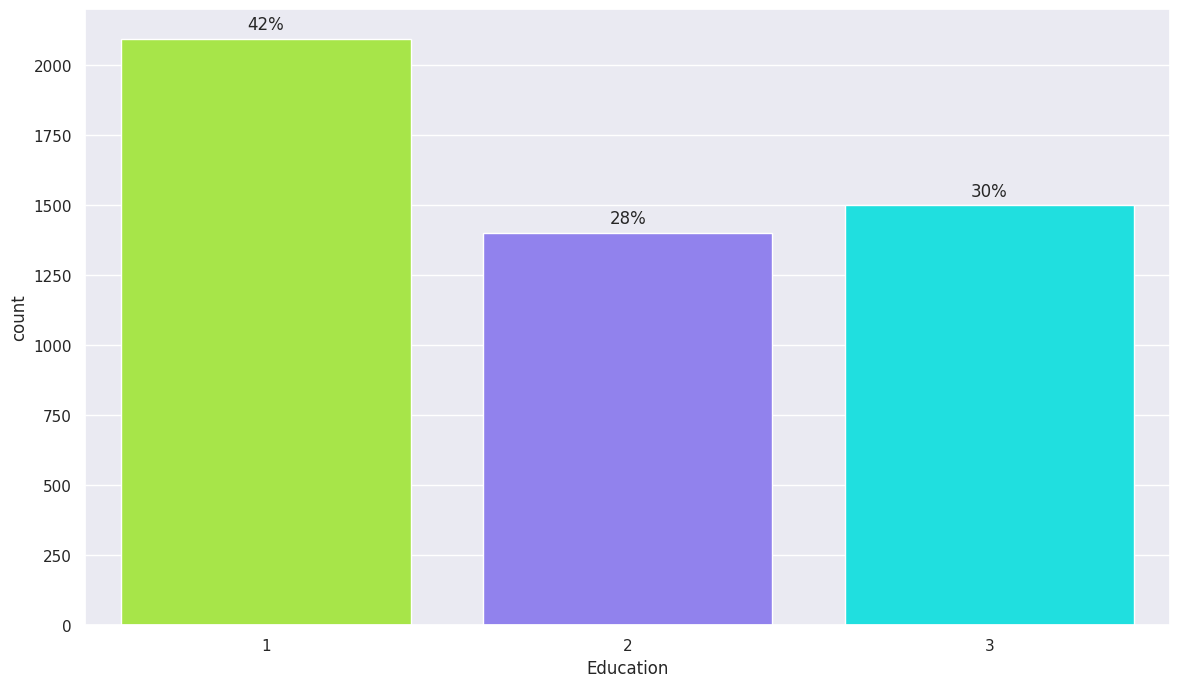

In [22]:
# Observations on Education Level
plt.figure(figsize=(14,8))
total = len(data['Education'])*1
qualitative_colors = ["#ADFF2F","#8470FF","#00FFFF","#FF1493"]
splot= sns.countplot(data=data, x='Education', palette=qualitative_colors)


for p in splot.patches:
    splot.annotate('{:.0f}%'.format(100*p.get_height()/total),
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va='center', xytext = (0,10), textcoords = 'offset points')
plt.show()

42% of the customers are undergraduates.
28% are graduates, and 30% have advanced studies.

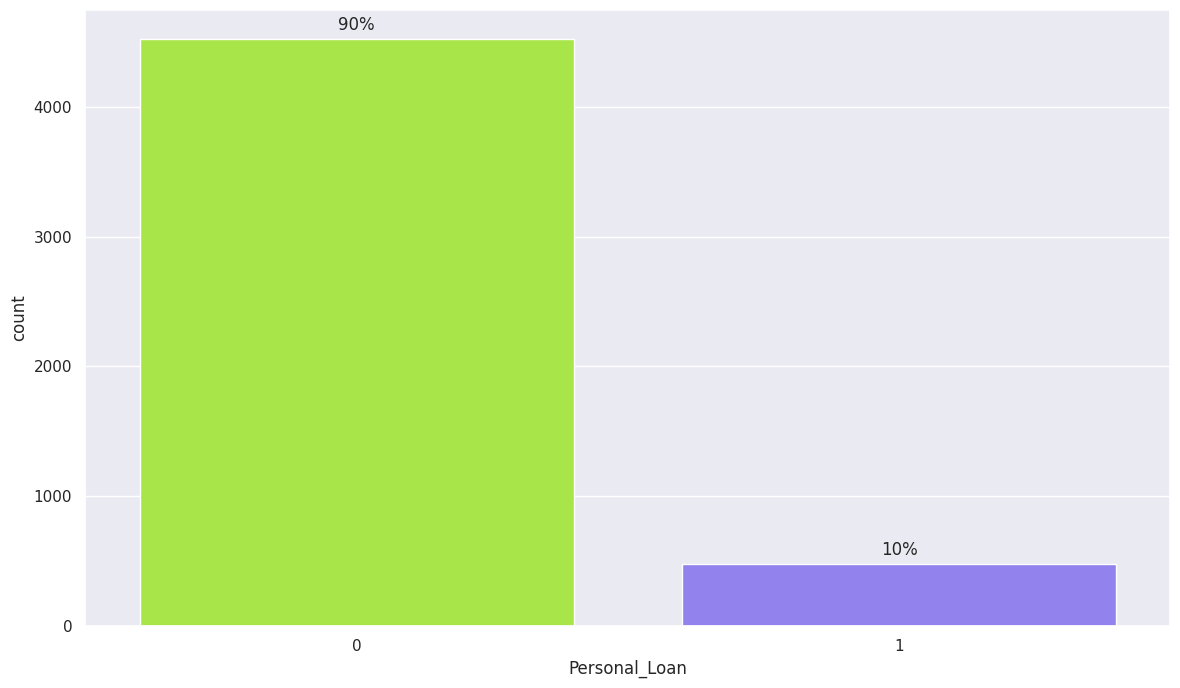

In [23]:
# Observations on Personal Loan
plt.figure(figsize=(14,8))
total = len(data['Personal_Loan'])*1
qualitative_colors = ["#ADFF2F","#8470FF"]
splot= sns.countplot(data=data, x='Personal_Loan', palette=qualitative_colors)


for p in splot.patches:
    splot.annotate('{:.0f}%'.format(100*p.get_height()/total),
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va='center', xytext = (0,10), textcoords = 'offset points')
plt.show()

The 90% of the customers did not accepted the personal loan last campaign while 10% accepted it.

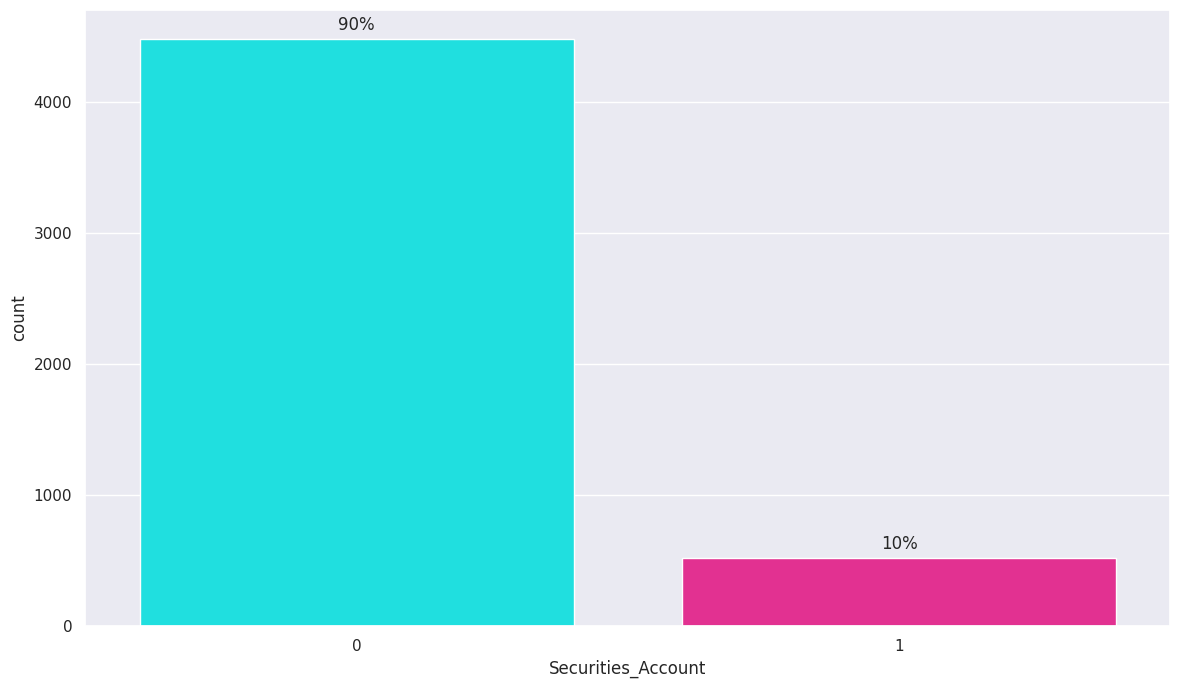

In [24]:
# Observations on Securities Account
plt.figure(figsize=(14,8))
total = len(data["Securities_Account"])*1
qualitative_colors = ["#00FFFF","#FF1493"]
splot= sns.countplot(data=data, x="Securities_Account", palette=qualitative_colors)


for p in splot.patches:
    splot.annotate('{:.0f}%'.format(100*p.get_height()/total),
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va='center', xytext = (0,10), textcoords = 'offset points')
plt.show()

The 90% of the customers do not have securities with the bank while the 10% have securities.

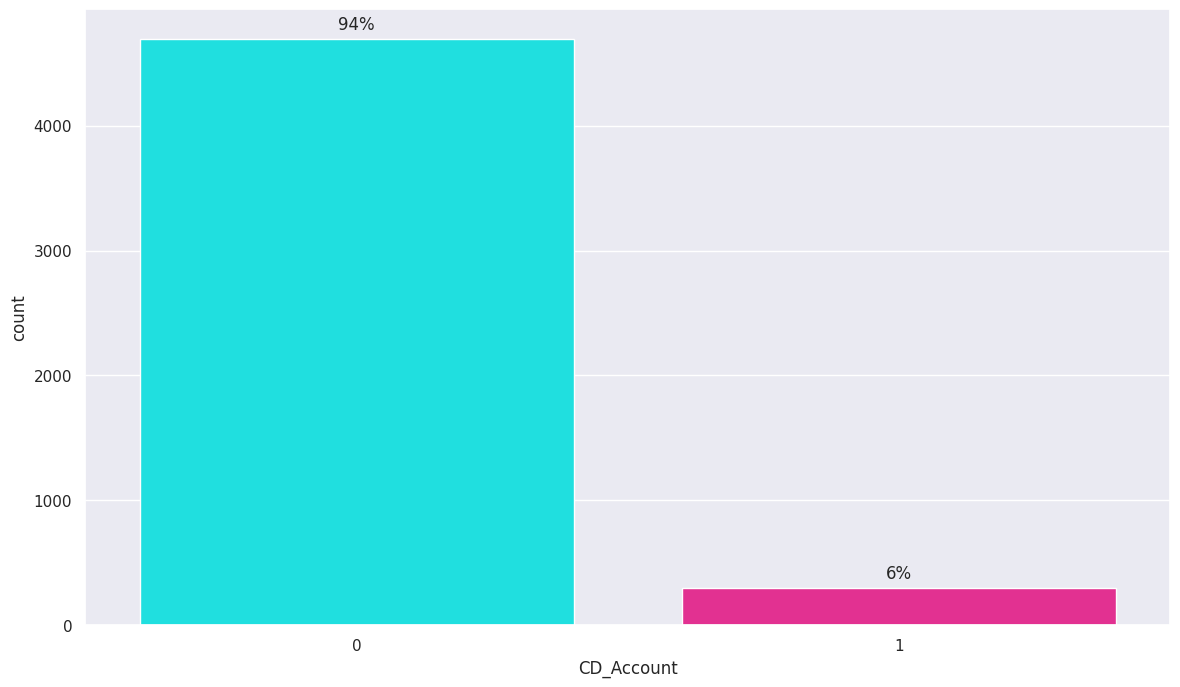

In [25]:
# Observations on CD Account
plt.figure(figsize=(14,8))
total = len(data["CD_Account"])*1
qualitative_colors = ["#00FFFF","#FF1493"]
splot= sns.countplot(data=data, x="CD_Account", palette=qualitative_colors)


for p in splot.patches:
    splot.annotate('{:.0f}%'.format(100*p.get_height()/total),
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va='center', xytext = (0,10), textcoords = 'offset points')
plt.show()

The 94% of the customers do not have certificate of deposits with the bank while the 6% have CD.

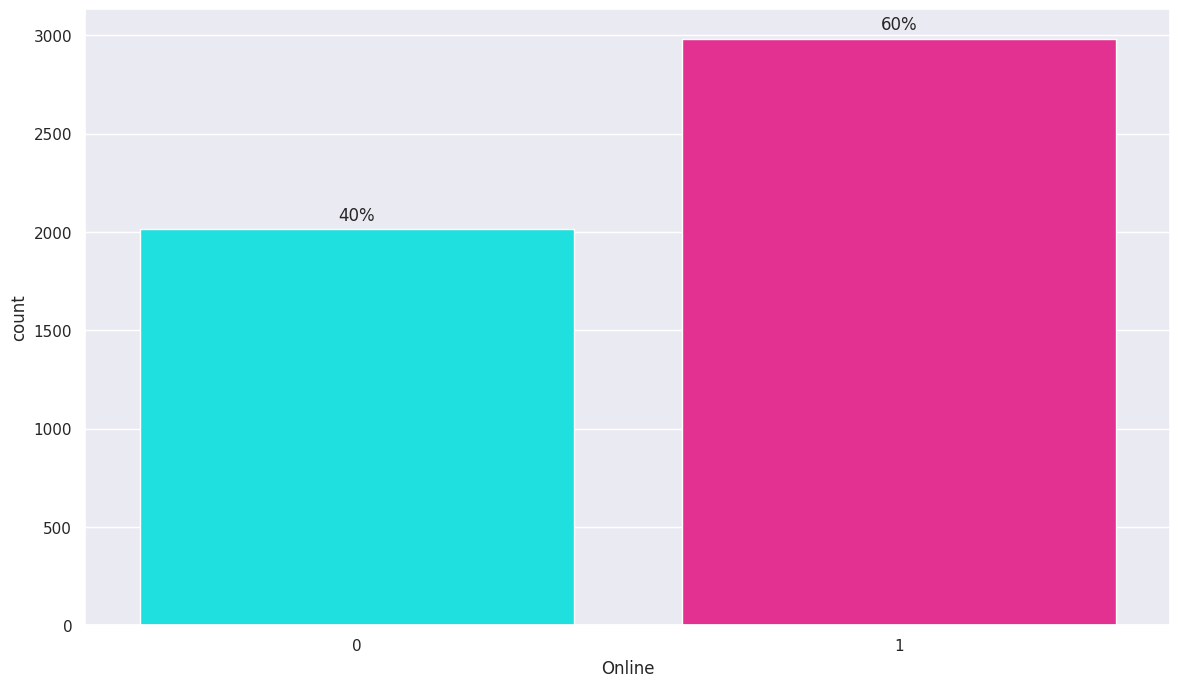

In [26]:
# Observations on Online Banking
plt.figure(figsize=(14,8))
total = len(data["Online"])*1
qualitative_colors = ["#00FFFF","#FF1493"]
splot= sns.countplot(data=data, x="Online", palette=qualitative_colors)


for p in splot.patches:
    splot.annotate('{:.0f}%'.format(100*p.get_height()/total),
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va='center', xytext = (0,10), textcoords = 'offset points')
plt.show()

The 40% of the customers do not have online banking facilities while the 60% have it.

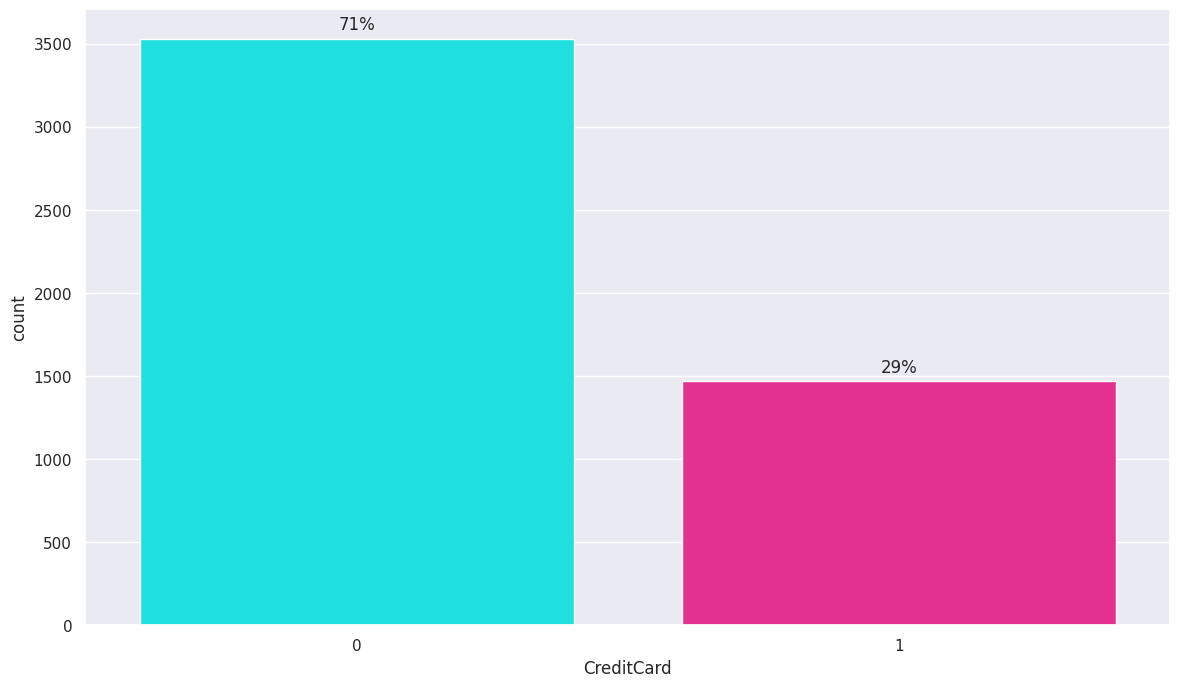

In [27]:
# Observations on Credit Card
plt.figure(figsize=(14,8))
total = len(data["CreditCard"])*1
qualitative_colors = ["#00FFFF","#FF1493"]
splot= sns.countplot(data=data, x="CreditCard", palette=qualitative_colors)


for p in splot.patches:
    splot.annotate('{:.0f}%'.format(100*p.get_height()/total),
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va='center', xytext = (0,10), textcoords = 'offset points')
plt.show()

The 71% of the customers do not have credit with other banks while 29.4 have it

### Bivariate Analysis

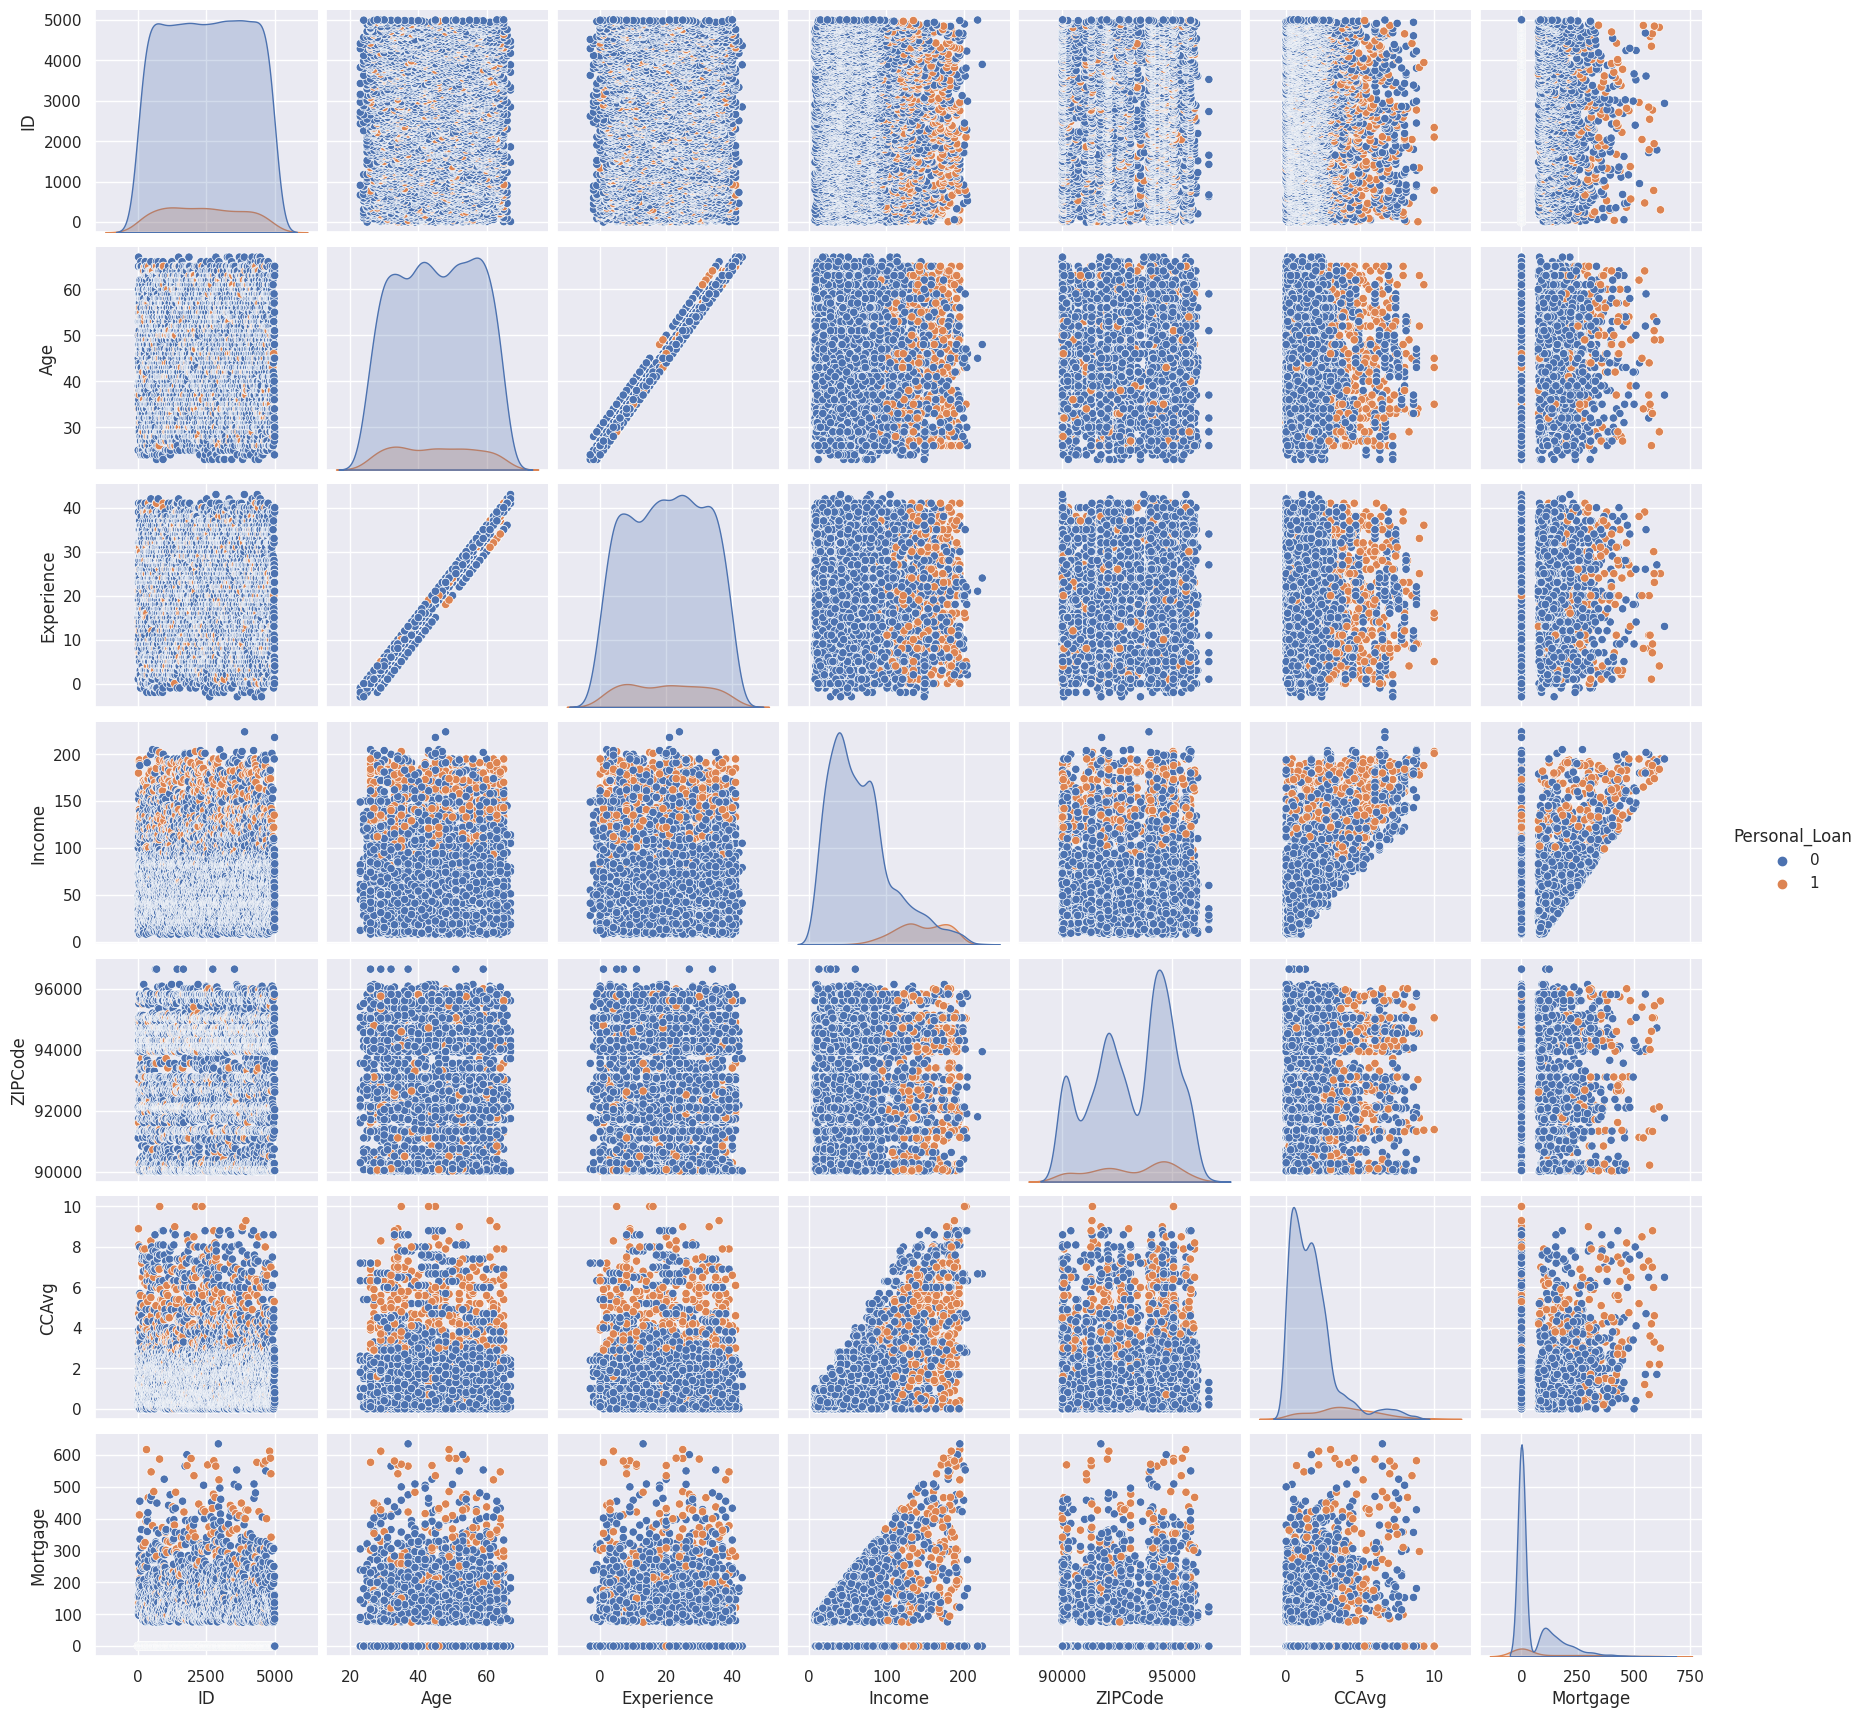

In [28]:
# Plot the pairplot
sns.pairplot(data, hue="Personal_Loan")
plt.show()

There is a strong correlation between age and experience, which is expected; however, no linear relationships are observed among the other variables.

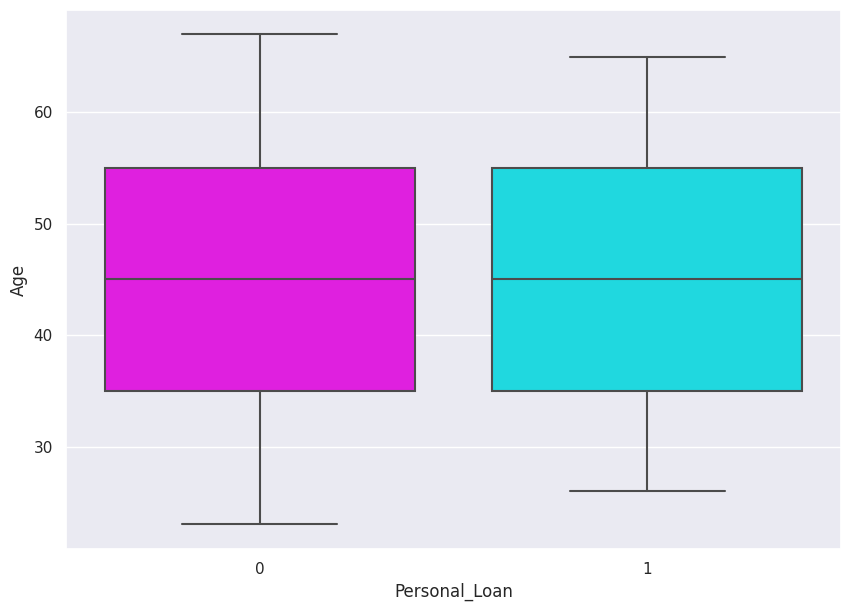

In [29]:
# Now let's review relationship between two variables 
# Boxplot between age and personal loan
sns.set(rc={"figure.figsize": (10, 7)})
palette= ["#FF00FF","#00F5FF"]
sns.set(palette=palette)
sns.boxplot(x="Personal_Loan", y="Age", data=data, orient="vertical")
plt.show()

There is no difference in the median age.
The age range is broader for customers who did not accept the loan last year.
No outliers are present.

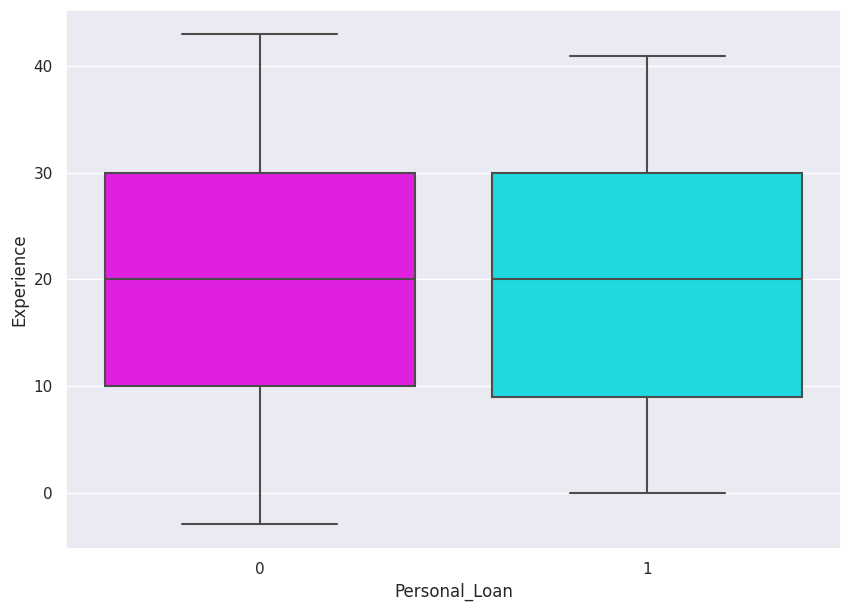

In [30]:
# Boxplot between experience and personal loan
sns.set(rc={"figure.figsize": (10, 7)})
palette= ["#FF00FF","#00F5FF"]
sns.set(palette=palette)
sns.boxplot(x="Personal_Loan", y="Experience", data=data, orient="vertical")
plt.show()

There is no difference in the median age.
The range of experience is broader for customers who do not have a loan.
No outliers are observed.

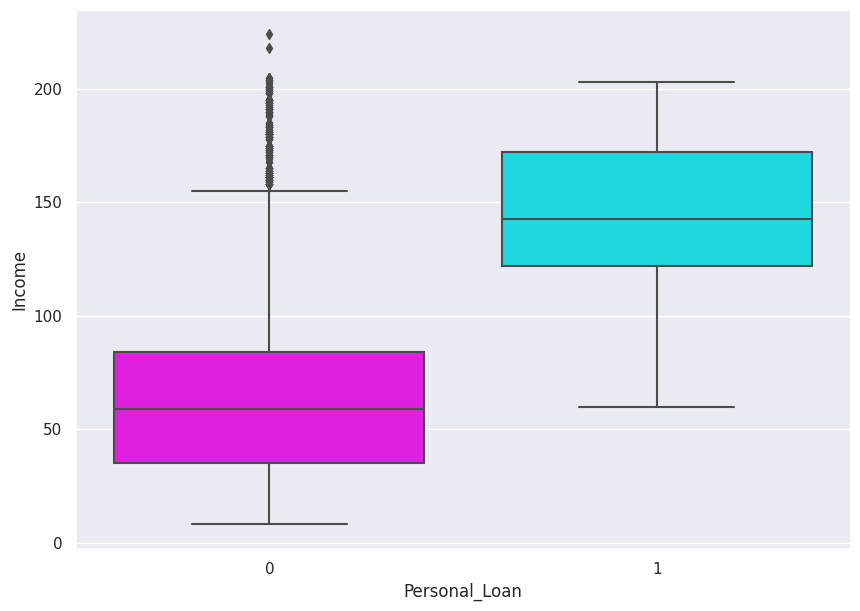

In [31]:
# Boxplot between income and personal loan
sns.set(rc={"figure.figsize": (10, 7)})
palette= ["#FF00FF","#00F5FF"]
sns.set(palette=palette)
sns.boxplot(x="Personal_Loan", y="Income", data=data, orient="vertical")
plt.show()

The median yearly income for customers with a loan is close to 150k, while for those without a loan, it is approximately 60k.
Customers who accepted the loan have a minimum income of 150k, with no outliers.
Outliers are present among customers without a loan.

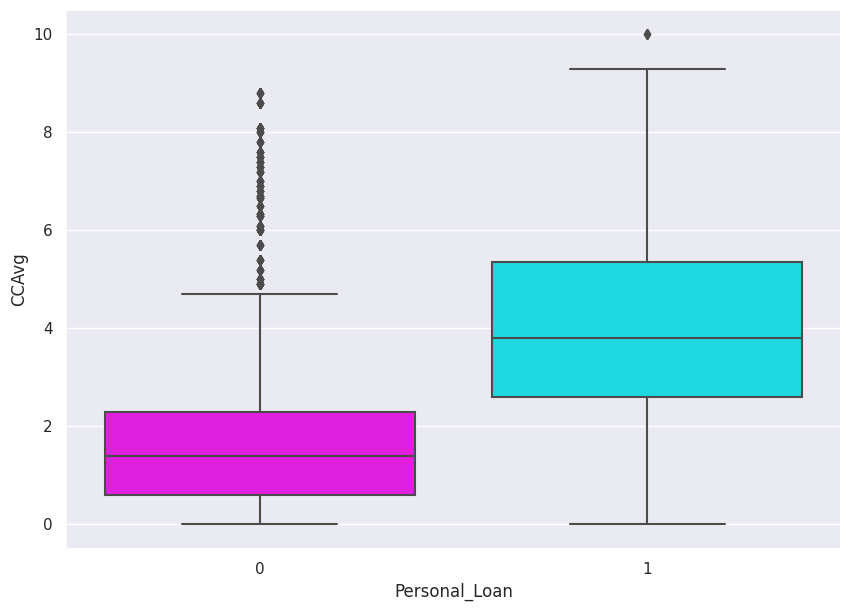

In [32]:
# Boxplot between credit card expenses and personal loan
sns.set(rc={"figure.figsize": (10, 7)})
palette= ["#FF00FF","#00F5FF"]
sns.set(palette=palette)
sns.boxplot(x="Personal_Loan", y="CCAvg", data=data, orient="vertical")
plt.show()

Customers who accepted the loan have a median monthly credit card expense of approximately 4k, while those without a loan spend less than 2k.
There is one outlier among customers with a personal loan and several outliers among customers without a loan.

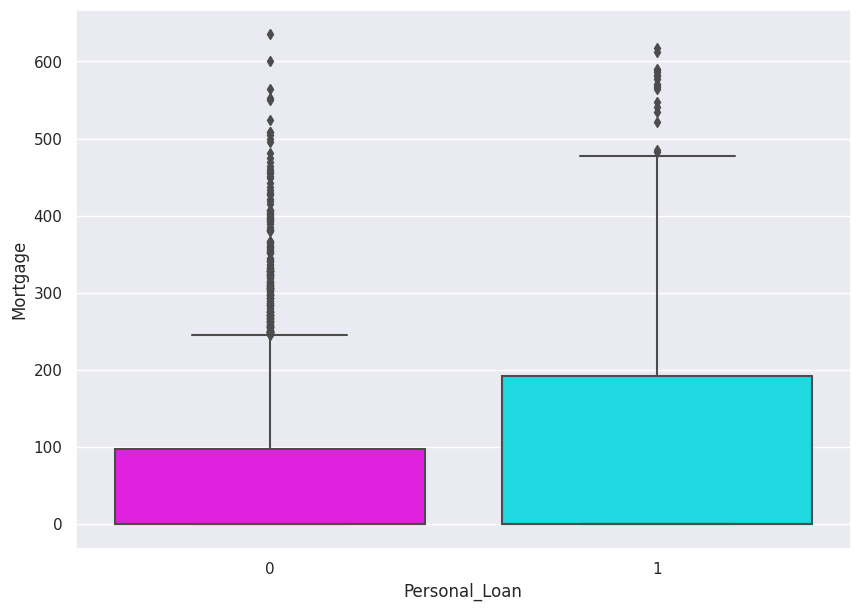

In [33]:
# Boxplot between mortgage value and personal loan
sns.set(rc={"figure.figsize": (10, 7)})
palette= ["#FF00FF","#00F5FF"]
sns.set(palette=palette)
sns.boxplot(x="Personal_Loan", y="Mortgage", data=data, orient="vertical")
plt.show()

The range of mortgage values is broader for customers with a personal loan compared to those without a loan.
Outliers are present in both groups, but they are more frequent among customers without a loan.

In [34]:
# No to look the relationship plotting stacked bar charts
def stacked_plot(x):
    palette= ["#00FA9A","#7B68EE"]
    sns.set(palette=palette)
    tab1 = pd.crosstab(x, data["Personal_Loan"], margins=True)
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(x, data["Personal_Loan"], normalize="index")
    tab.plot(kind="bar", stacked=True, figsize=(10, 5))
    # plt.legend(loc='lower left', frameon=False)
    # plt.legend(loc="upper left", bbox_to_anchor=(0,1))
    plt.show()

Personal_Loan     0    1   All
Family                        
1              1365  107  1472
2              1190  106  1296
3               877  133  1010
4              1088  134  1222
All            4520  480  5000
------------------------------------------------------------------------------------------------------------------------


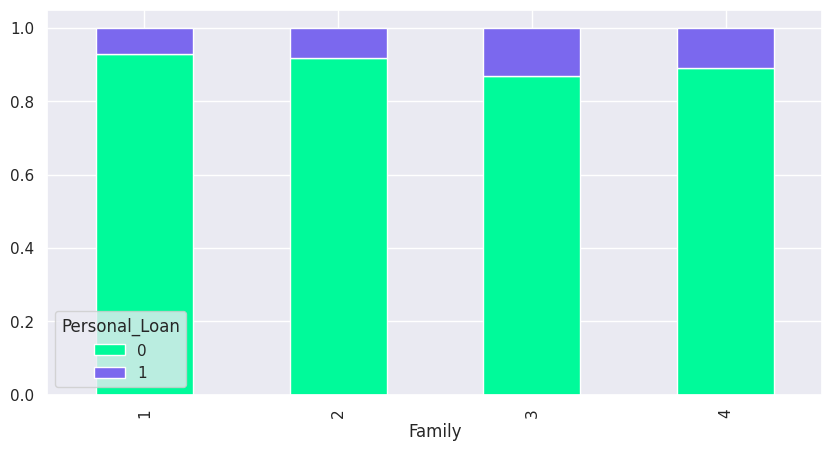

In [35]:
# Stacked plot between family and personal loan
stacked_plot(data["Family"])

The majority of customers who accepted the loan had a family size of three.

Personal_Loan     0    1   All
Education                     
1              2003   93  2096
2              1221  182  1403
3              1296  205  1501
All            4520  480  5000
------------------------------------------------------------------------------------------------------------------------


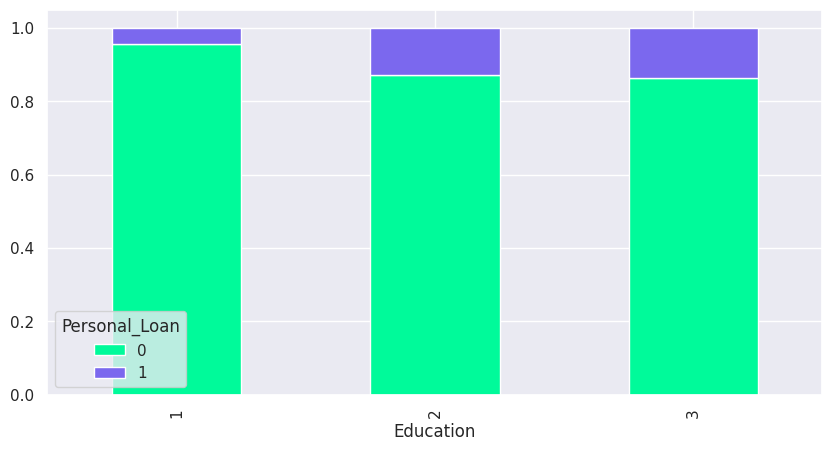

In [36]:
# Stacked plot between educaction level and personal loan
stacked_plot(data["Education"])

The majority of customers who accepted the loan were graduates.

Personal_Loan          0    1   All
Securities_Account                 
0                   4058  420  4478
1                    462   60   522
All                 4520  480  5000
------------------------------------------------------------------------------------------------------------------------


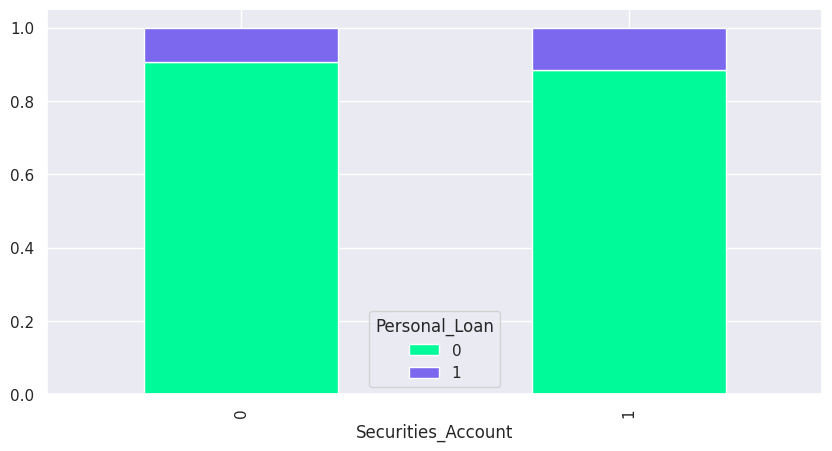

In [37]:
# Stacked plot between securities account and personal loan
stacked_plot(data["Securities_Account"])

The majority of customers who accepted the loan have securities with the bank.

Personal_Loan     0    1   All
CD_Account                    
0              4358  340  4698
1               162  140   302
All            4520  480  5000
------------------------------------------------------------------------------------------------------------------------


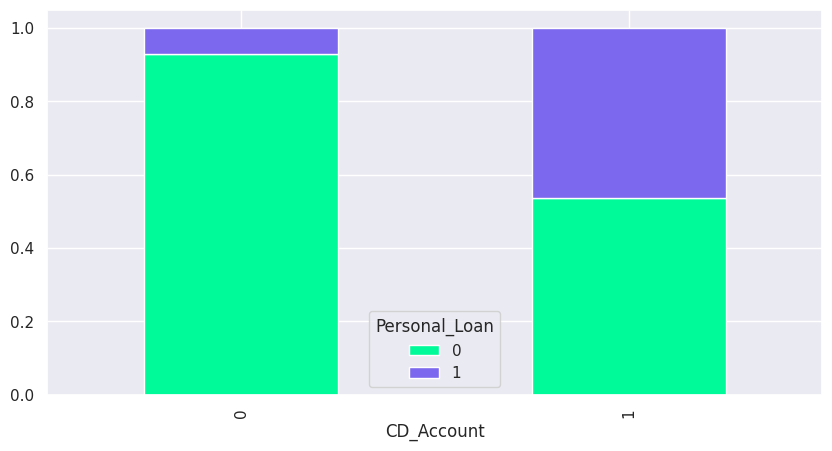

In [38]:
# Stacked plot between certificate of deposits account and personal loan
stacked_plot(data["CD_Account"])

The majority of customers who accepted the loan hold more securities with the bank.

Personal_Loan     0    1   All
CD_Account                    
0              4358  340  4698
1               162  140   302
All            4520  480  5000
------------------------------------------------------------------------------------------------------------------------


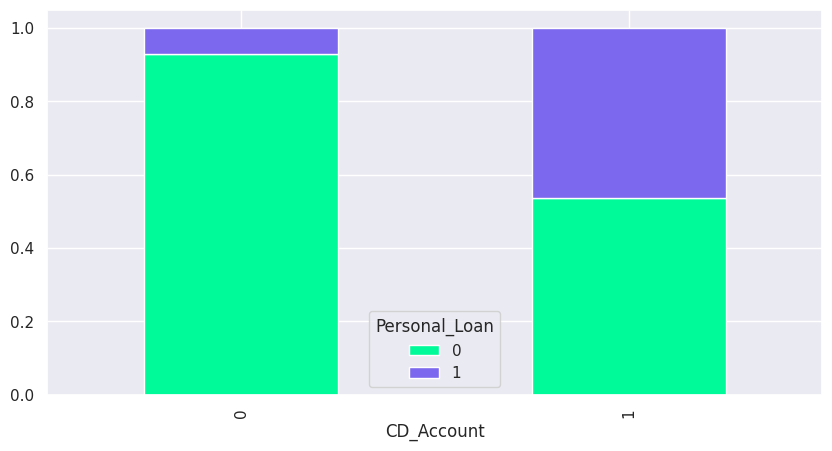

In [39]:
# Stacked plot between certificate of deposits account and personal loan
stacked_plot(data["CD_Account"])

The majority of the customers that accepted the loan have a certificate of deposits with the bank.

Personal_Loan     0    1   All
Online                        
0              1827  189  2016
1              2693  291  2984
All            4520  480  5000
------------------------------------------------------------------------------------------------------------------------


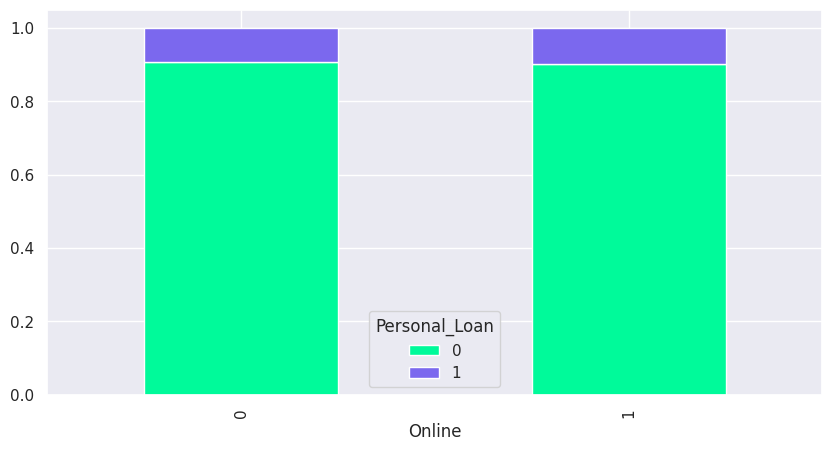

In [40]:
# Stacked plot between online services and personal loan
stacked_plot(data["Online"])

The majority of the customers that accepted the loan have online services with the bank but the difference is not big.

Personal_Loan     0    1   All
CreditCard                    
0              3193  337  3530
1              1327  143  1470
All            4520  480  5000
------------------------------------------------------------------------------------------------------------------------


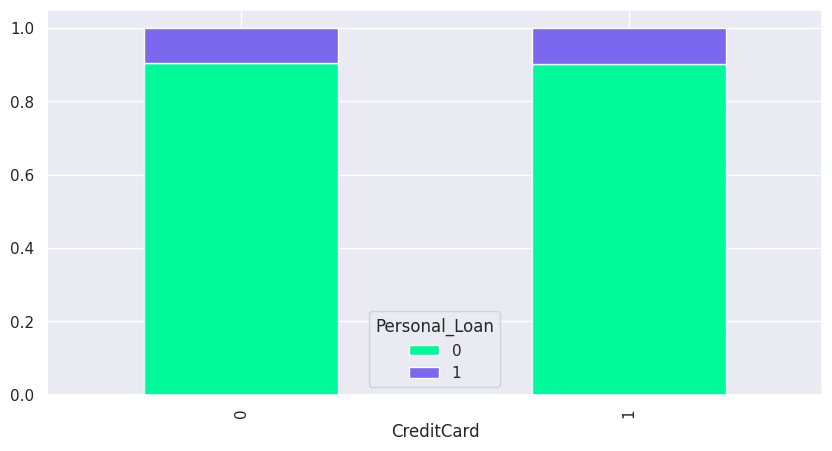

In [41]:
# Stacked plot between credit card and personal loan
stacked_plot(data["CreditCard"])


There is no relevant different between the customers.

<Axes: >

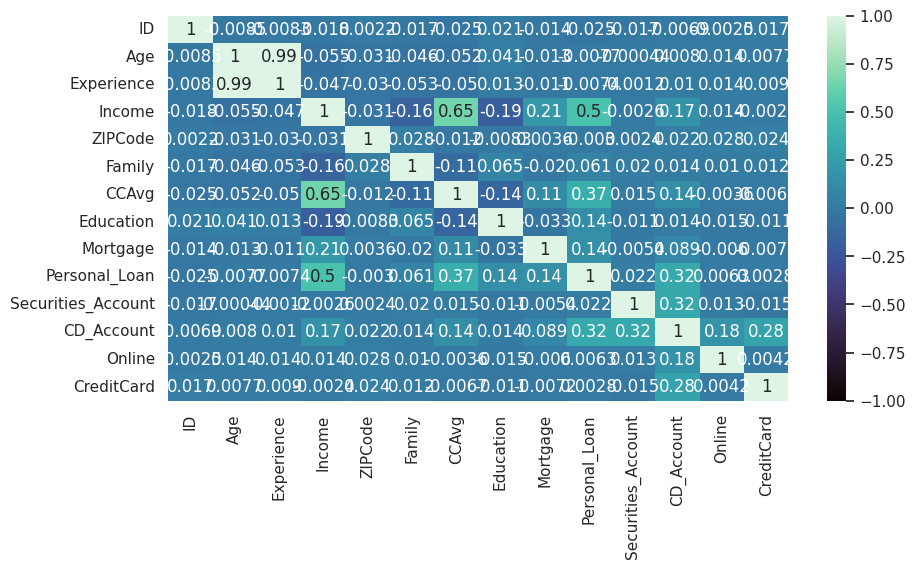

In [42]:
# To plot the correlation coefficients in a heatmap
plt.figure(figsize=(10,5))
correlation= data.corr()
sns.heatmap(correlation, vmax=1,vmin=-1, annot=True, cmap='mako')

There is a strong positive correlation between age and experience.
A correlation is also observed between credit card expenses and income levels.
The remaining variables do not show any significant correlations.

### Additional Data Preparation

In [43]:
# let's treat multicollinearity
# We are going to drop experience 
data = data.drop(['Experience'],axis=1) 
data.head()

,ID,Age,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,45,91330,4,1.0,2,0,0,0,0,0,1


In [44]:
# We are going to drop some columns
data = data.drop(['ZIPCode','ID'],axis=1) 
data.head()

,Age,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,25,49,4,1.6,1,0,0,1,0,0,0
1,45,34,3,1.5,1,0,0,1,0,0,0
2,39,11,1,1.0,1,0,0,0,0,0,0
3,35,100,1,2.7,2,0,0,0,0,0,0
4,35,45,4,1.0,2,0,0,0,0,0,1


### Model Building
#### Logistic Regression

The dataset we are working with does not include any information about customers who have taken loans but failed to repay them (loan-delinquent customers). This means we cannot evaluate or account for the risk of potential default, which is an important consideration in real-world banking. Instead, our focus is on identifying customers who are most likely to accept a loan.

In this context, the inability to correctly identify a customer who would accept a loan represents the biggest missed opportunity. Why? Because if the model overlooks such a customer, the bank loses out on potential revenue and an opportunity to grow its loan business.

If the model predicts that a customer will not take a loan (even though they would have), the bank misses the chance to market the loan to them.
On the other hand, customers who accept loans are a valuable group for the bank, as these transactions generate profits. Therefore, our primary goal with this dataset is to maximize the accuracy of identifying potential loan customers while ensuring minimal errors in predictions.
Although this dataset is simplified and doesn't address every real-world scenario (like managing default risks), it serves as a valuable exercise in understandi

In [45]:
##  Function to calculate different metric scores of the model - Accuracy, Recall, Misclassification and Precision
def get_metrics_score(model,train,test,train_y,test_y,flag=True):
   
    score_list=[] 
    
    pred_train = model.predict(train)
    pred_test = model.predict(test)
    
    train_acc = accuracy_score(pred_train,train_y)
    test_acc = accuracy_score(pred_test,test_y)
    
    train_recall = recall_score(train_y,pred_train)
    test_recall = recall_score(test_y,pred_test)
    
    train_precision = precision_score(train_y,pred_train)
    test_precision = precision_score(test_y,pred_test)
    
    train_misclassification = (1-accuracy_score(pred_train,train_y))
    test_misclassification = (1-accuracy_score(pred_test,test_y))
    
    
    score_list.extend((train_acc,test_acc,train_recall,test_recall,train_precision,test_precision,train_misclassification,test_misclassification ))
        
     # If the flag is set to True then only the following print statements will be dispayed. The default value is set to True.
    if flag == True: 
        print("Accuracy on training set : ",accuracy_score(pred_train,train_y))
        print("Accuracy on test set : ",accuracy_score(pred_test,test_y))
        print("Recall on training set : ",recall_score(train_y,pred_train))
        print("Recall on test set : ",recall_score(test_y,pred_test))
        print("Precision on training set : ",precision_score(train_y,pred_train))
        print("Precision on test set : ",precision_score(test_y,pred_test))
        print("Misclassification on training set : ", 1-accuracy_score(pred_train,train_y))
        print("Misclassification on test set : ", 1-accuracy_score(pred_test,test_y))
    
    return score_list # returning the list with train and test scores

In [46]:
# defining a function to build a confusion matrix
def make_confusion_matrix(model,test_X,y_actual,labels=[1, 0]):
    '''
    model : classifier to predict values of X
    y_actual : ground truth  
    
    '''
    y_predict = model.predict(test_X)
    cm=metrics.confusion_matrix( y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index = [i for i in ["Actual - No","Actual - Yes"]],
                  columns = [i for i in ['Predicted - No','Predicted - Yes']])
    group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in
                         cm.flatten()/np.sum(cm)]
    labels = [f"{v1}\n{v2}" for v1, v2 in
              zip(group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    plt.figure(figsize = (10,7))
    sns.heatmap(df_cm, annot=labels,fmt='')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [47]:
# split the data
X = data.drop('Personal_Loan',axis=1)
Y = data['Personal_Loan']

# splitting in training and test set
X_train, X_test, y_train, y_test = train_test_split( X, Y, test_size = 0.3, random_state = 42)

In [48]:
# dataframe with numerical column only
num_feature_set = X.copy()
num_feature_set = add_constant(num_feature_set)
num_feature_set = num_feature_set.astype(float)

In [49]:
# Identify series before future selection
vif_series1 = pd.Series([variance_inflation_factor(num_feature_set.values,i) for i in range(num_feature_set.shape[1])],index=num_feature_set.columns, dtype = float)
print('Series before feature selection: \n\n{}\n'.format(vif_series1))

Series before feature selection: 

const                 35.039069
Age                    1.008374
Income                 1.854712
Family                 1.032291
CCAvg                  1.723904
Education              1.044019
Mortgage               1.051253
Securities_Account     1.136822
CD_Account             1.328768
Online                 1.039524
CreditCard             1.107883
dtype: float64



In this section, we are calculating the Variance Inflation Factor (VIF) for the features in the dataset before performing feature selection.

What is VIF and Why is it Important?
VIF measures the degree of multicollinearity among features in a dataset.
Multicollinearity occurs when two or more features are highly correlated, meaning they carry redundant information. This can lead to instability in regression models, making it difficult to interpret coefficients and affecting model predictions.
A high VIF value (typically greater than 5 or 10) indicates multicollinearity and suggests that the feature should potentially be removed to improve the model's performance.

const: The constant term in regression has a very high VIF (35.039069). This is expected, as it does not add predictive value but is required for the model. It can be ignored when assessing multicollinearity.

Other Features: Most features have VIF values close to or below 2. This indicates low multicollinearity among them. Features like Income (1.854712) and CCAvg (1.723904) have slightly higher values but are still within an acceptable range.

Since the VIF values for all features (except const) are low, multicollinearity does not appear to be a major issue in this dataset. Therefore, no features need to be removed based on VIF alone.

In [50]:
# build the logistic regression model
model = LogisticRegression(random_state=1)
lg = model.fit(X_train,y_train)

Accuracy on training set :  0.9385714285714286
Accuracy on test set :  0.9386666666666666
Recall on training set :  0.5015479876160991
Recall on test set :  0.5286624203821656
Precision on training set :  0.75
Precision on test set :  0.8217821782178217
Misclassification on training set :  0.06142857142857139
Misclassification on test set :  0.06133333333333335


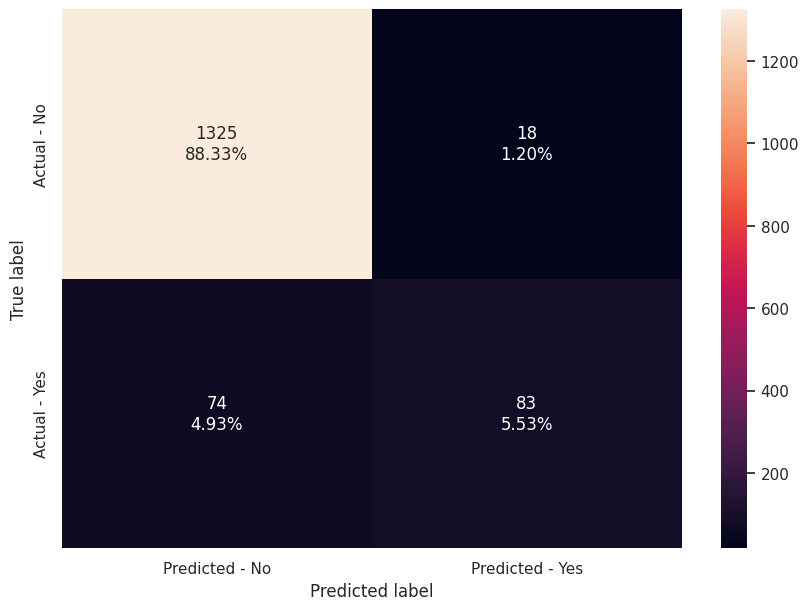

In [51]:
scores_LR = get_metrics_score(lg,X_train,X_test,y_train,y_test,flag=True)

# creating confusion matrix
make_confusion_matrix(lg,X_test,y_test)

The confusion matrix:

    True Positives (TP): Correctly predicted 83 customers buying the loan

    True Negatives (TN): Correctly predicted 1325 customers not buying the loan

    False Positives (FP): Incorrectly predicted 18 customers buying the loan (type error I)

    False Negatives (FN): Incorrectly predicted 74 customers not buying the loan (type error II)



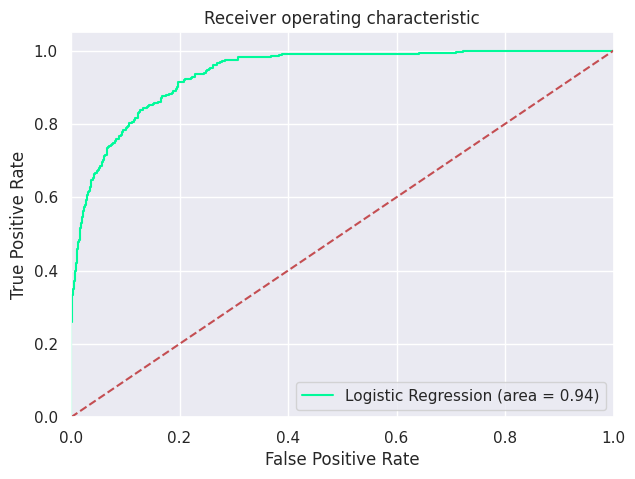

In [52]:
# Let's build the ROC curve
logit_roc_auc_train = roc_auc_score(y_train, lg.predict_proba(X_train)[:,1])
fpr, tpr, thresholds = roc_curve(y_train, lg.predict_proba(X_train)[:,1])
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc_train)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

The AUC (Area Under the Curve) is reported as 0.94, which is a strong indicator of the model's performance. An AUC of 0.94 means the model is highly effective at distinguishing between positive and negative classes.

In [53]:
# Finding the coefficients
log_odds = lg.coef_[0]
pd.DataFrame(log_odds, X_train.columns, columns=['coef']).T

,Age,Income,Family,CCAvg,Education,Mortgage,Securities_Account,CD_Account,Online,CreditCard
coef,-0.028245,0.036118,0.378059,0.06288,0.721039,0.000346,-0.360221,4.265602,-1.899503,-1.522139


### **Feature Interpretations**

1. **Age**: `-0.028245`
   - A negative value means that older customers are slightly less likely to accept a loan.
   - However, the impact is small due to the low magnitude of the coefficient.

2. **Income**: `0.036118`
   - A positive coefficient indicates that customers with higher income are slightly more likely to accept a loan.

3. **Family**: `0.378059`
   - Customers with larger family sizes are more likely to accept a loan.
   - The relatively higher magnitude suggests this is a stronger predictor compared to features like age or income.

4. **CCAvg (Credit Card Average Spending)**: `0.06288`
   - A small positive coefficient indicates that customers who spend more on credit cards are slightly more likely to accept a loan.

5. **Education**: `0.721039`
   - A positive and relatively high coefficient suggests that customers with higher education levels are significantly more likely to accept a loan. This is one of the stronger predictors.

6. **Mortgage**: `0.000346`
   - A near-zero coefficient indicates that the mortgage value has an almost negligible impact on loan acceptance.

7. **Securities_Account**: `-0.360221`
   - Customers with securities accounts are less likely to accept a loan.

8. **CD_Account (Certificate of Deposit)**: `4.265602`
   - A very high positive coefficient shows that customers with a certificate of deposit (CD) account are much more likely to accept a loan. This is the **strongest predictor** in the dataset.

9. **Online**: `-1.899503`
   - A large negative coefficient shows that customers using online banking are significantly less likely to accept a loan.

10. **CreditCard**: `-1.522139`
    - A negative coefficient suggests that customers using a credit card issued by another bank are less likely to accept a loan.

---

### **Insights**

- **Key Positive Predictors**:
  - **CD_Account**: The strongest positive impact; customers with a certificate of deposit account are highly likely to accept a loan.
  - **Education**: Higher education levels significantly increase the likelihood of loan acceptance.
  - **Family**: Larger family size is also a notable positive predictor.

- **Key Negative Predictors**:
  - **Online**: Customers using online banking are significantly less likely to accept a loan.
  - **CreditCard**: Customers with a credit card from another bank are less likely to accept a loan.
  - **Securities_Account**: Customers with securities accounts are less likely to accept a loan, but the effect is less pronounced compared to "Online" and "CreditCard."

---

### Finding optimal threshold

In [54]:
# Optimal threshold as per AUC-ROC curve
# The optimal cut off would be where tpr is high and fpr is low
fpr, tpr, thresholds = metrics.roc_curve(y_test, lg.predict_proba(X_test)[:,1])

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(optimal_threshold)

0.14082313603985774


In [55]:
# Model prediction with optimal threshold
pred_train_opt = (lg.predict(X_train)>optimal_threshold).astype(int)
pred_test_opt = (lg.predict(X_test)>optimal_threshold).astype(int)

In [56]:
# Model performance with optimal threhold

print('Accuracy on train data:',accuracy_score(y_train, pred_train_opt) )
print('Accuracy on test data:',accuracy_score(y_test, pred_test_opt))

print('Recall on train data:',recall_score(y_train, pred_train_opt))
print('Recall on test data:',recall_score(y_test, pred_test_opt))

print('Precision on train data:',precision_score(y_train, pred_train_opt) )
print('Precision on test data:',precision_score(y_test, pred_test_opt))

print("Misclassification on training set : ", 1-accuracy_score(y_train, pred_train_opt))
print("Misclassification on test set : ", 1-accuracy_score(y_test, pred_test_opt))

Accuracy on train data: 0.9385714285714286
Accuracy on test data: 0.9386666666666666
Recall on train data: 0.5015479876160991
Recall on test data: 0.5286624203821656
Precision on train data: 0.75
Precision on test data: 0.8217821782178217
Misclassification on training set :  0.06142857142857139
Misclassification on test set :  0.06133333333333335


There is no change in the model performance

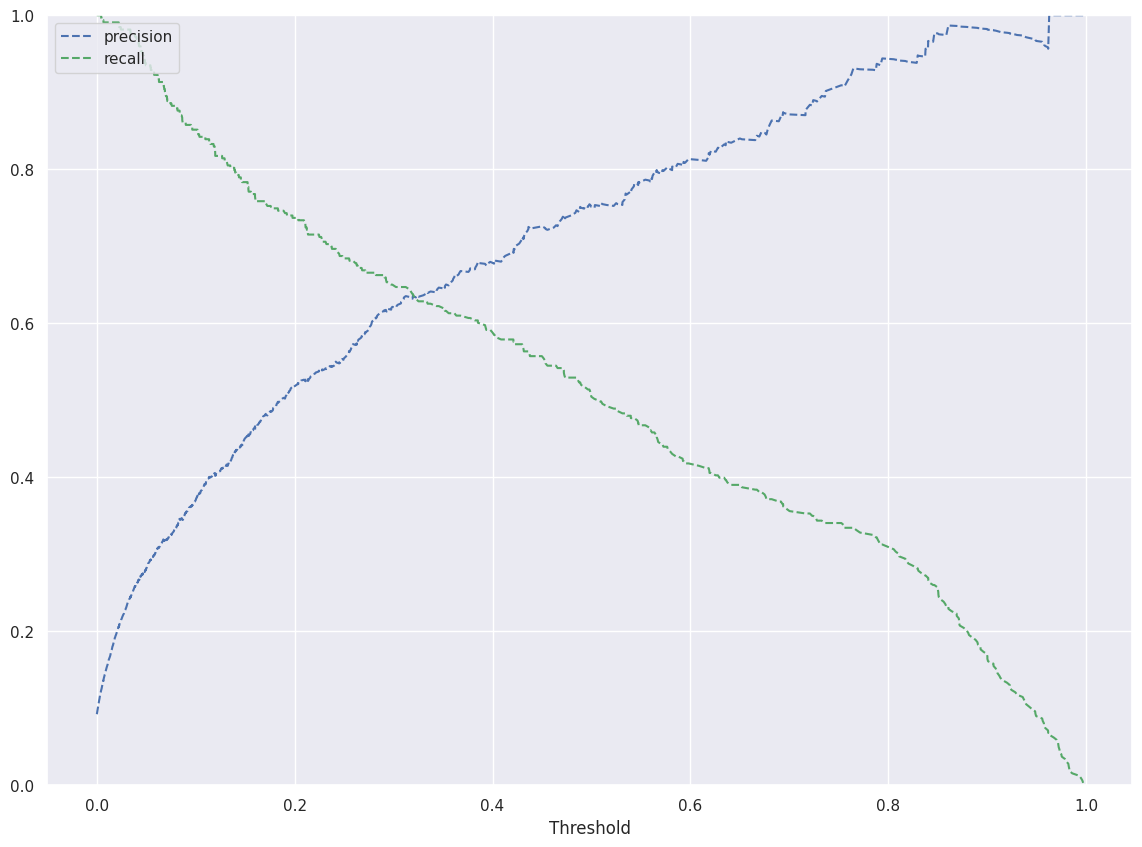

In [57]:
# Precision-Recall curve and see if we can find a better threshold
y_scores=lg.predict_proba(X_train)[:,1]
prec, rec, tre = precision_recall_curve(y_train, y_scores,)

def plot_prec_recall_vs_tresh(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], 'b--', label='precision')
    plt.plot(thresholds, recalls[:-1], 'g--', label = 'recall')
    plt.xlabel('Threshold')
    plt.legend(loc='upper left')
    plt.ylim([0,1])
plt.figure(figsize=(14,10))
plot_prec_recall_vs_tresh(prec, rec, tre)
plt.show()

At threshold around 0.32 we will get equal precision and recall, but if a threshold of 0.20 the values will be better.

In [58]:
optimal_threshold = 0.20

# Model prediction with optimal threshold
pred_train_opt = (lg.predict_proba(X_train)[:,1]>optimal_threshold)
pred_test_opt = (lg.predict_proba(X_test)[:,1]>optimal_threshold)

#Model performance with optimal threhold

print('Accuracy on train data:',accuracy_score(y_train, pred_train_opt) )
print('Accuracy on test data:',accuracy_score(y_test, pred_test_opt))

print('Recall on train data:',recall_score(y_train, pred_train_opt))
print('Recall on test data:',recall_score(y_test, pred_test_opt))

print('Precision on train data:',precision_score(y_train, pred_train_opt) )
print('Precision on test data:',precision_score(y_test, pred_test_opt))

print("Misclassification on training set : ", 1-accuracy_score(y_train, pred_train_opt))
print("Misclassification on test set : ", 1-accuracy_score(y_test, pred_test_opt))


print('ROC-AUC Score on train data:',roc_auc_score(y_train, pred_train_opt) )
print('ROC-AUC Score on test data:',roc_auc_score(y_test, pred_test_opt))

Accuracy on train data: 0.9125714285714286
Accuracy on test data: 0.9106666666666666
Recall on train data: 0.7368421052631579
Recall on test data: 0.7961783439490446
Precision on train data: 0.5185185185185185
Precision on test data: 0.5506607929515418
Misclassification on training set :  0.08742857142857141
Misclassification on test set :  0.08933333333333338
ROC-AUC Score on train data: 0.8336398124679025
ROC-AUC Score on test data: 0.8601144884302185


Accuracy have declined but recall has improved significantly.
Precision in train and test data are now similar.



### Model Building - Decision Tree 

In [59]:
# Now let's build a decision tree model using gini criteria to split
model = DecisionTreeClassifier(criterion = 'gini', random_state=1)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

In [60]:
# accuracy on training set
print("Accuracy on train set", model.score(X_train, y_train))

# accuracy on test set
print("Accuracy on test set", model.score(X_test, y_test))

# Check misclassification error
print("Misclassification on training set : ", 1-model.score(X_train, y_train))
print("Misclassification on test set : ", 1-model.score(X_test, y_test))

Accuracy on train set 1.0
Accuracy on test set 0.9806666666666667
Misclassification on training set :  0.0
Misclassification on test set :  0.019333333333333313


In [61]:
## Function to create confusion matrix
def make_confusion_matrix(model,y_actual,labels=[1, 0]):
    '''
    model : classifier to predict values of X
    y_actual : ground truth  
    
    '''
    y_predict = model.predict(X_test)
    cm=metrics.confusion_matrix( y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index = [i for i in ["Actual - No","Actual - Yes"]],
                  columns = [i for i in ['Predicted - No','Predicted - Yes']])
    group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in
                         cm.flatten()/np.sum(cm)]
    labels = [f"{v1}\n{v2}" for v1, v2 in
              zip(group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    plt.figure(figsize = (10,7))
    sns.heatmap(df_cm, annot=labels,fmt='')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

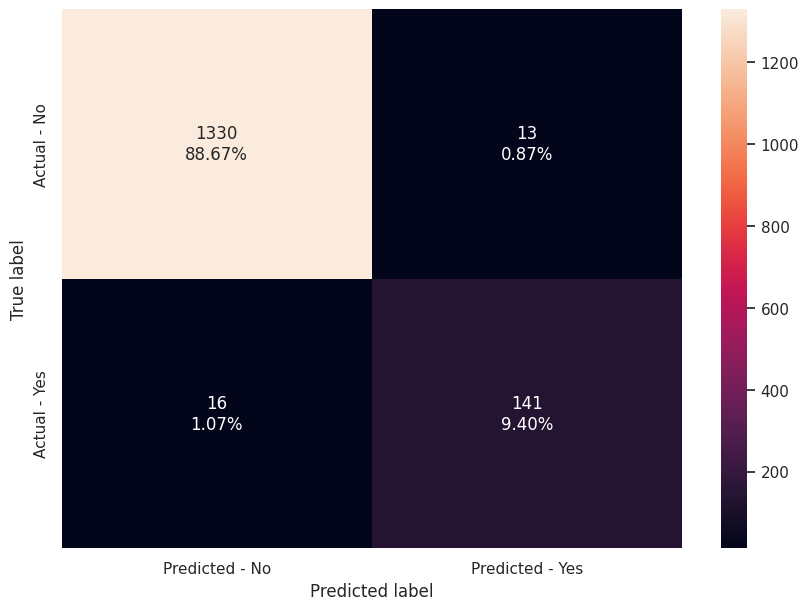

In [62]:
make_confusion_matrix(model,y_test)

In [63]:
y_train.value_counts(1)

Personal_Loan
0    0.907714
1    0.092286
Name: proportion, dtype: float64

The confusion matrix:

- True Positives (TP): 
    Correctly predicted 141 customers buying the loan
        
- True Negatives (TN): 
    Correctly predicted 1330 customers not buying the loan
       
- False Positives (FP): 
    Incorrectly predicted 13 customers buying the loan (type error I)
   
- False Negatives (FN): 
    Incorrectly predicted 16 customers not buying the loan (type error II)

In [64]:
##  Function to calculate recall score
def get_recall_score(model):
    '''
    model : classifier to predict values of X

    '''
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    print("Recall on training set : ",metrics.recall_score(y_train,pred_train))
    print("Recall on test set : ",metrics.recall_score(y_test,pred_test))

In [65]:
get_recall_score(model)

Recall on training set :  1.0
Recall on test set :  0.8980891719745223


Recall on training and test set is not too different, but still the model suggest overfitting.

### Visualizing the Decision Tree

In [66]:
# Let's print the features names
column_names = list(X.columns)
feature_names = column_names
print(feature_names)

['Age', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard']


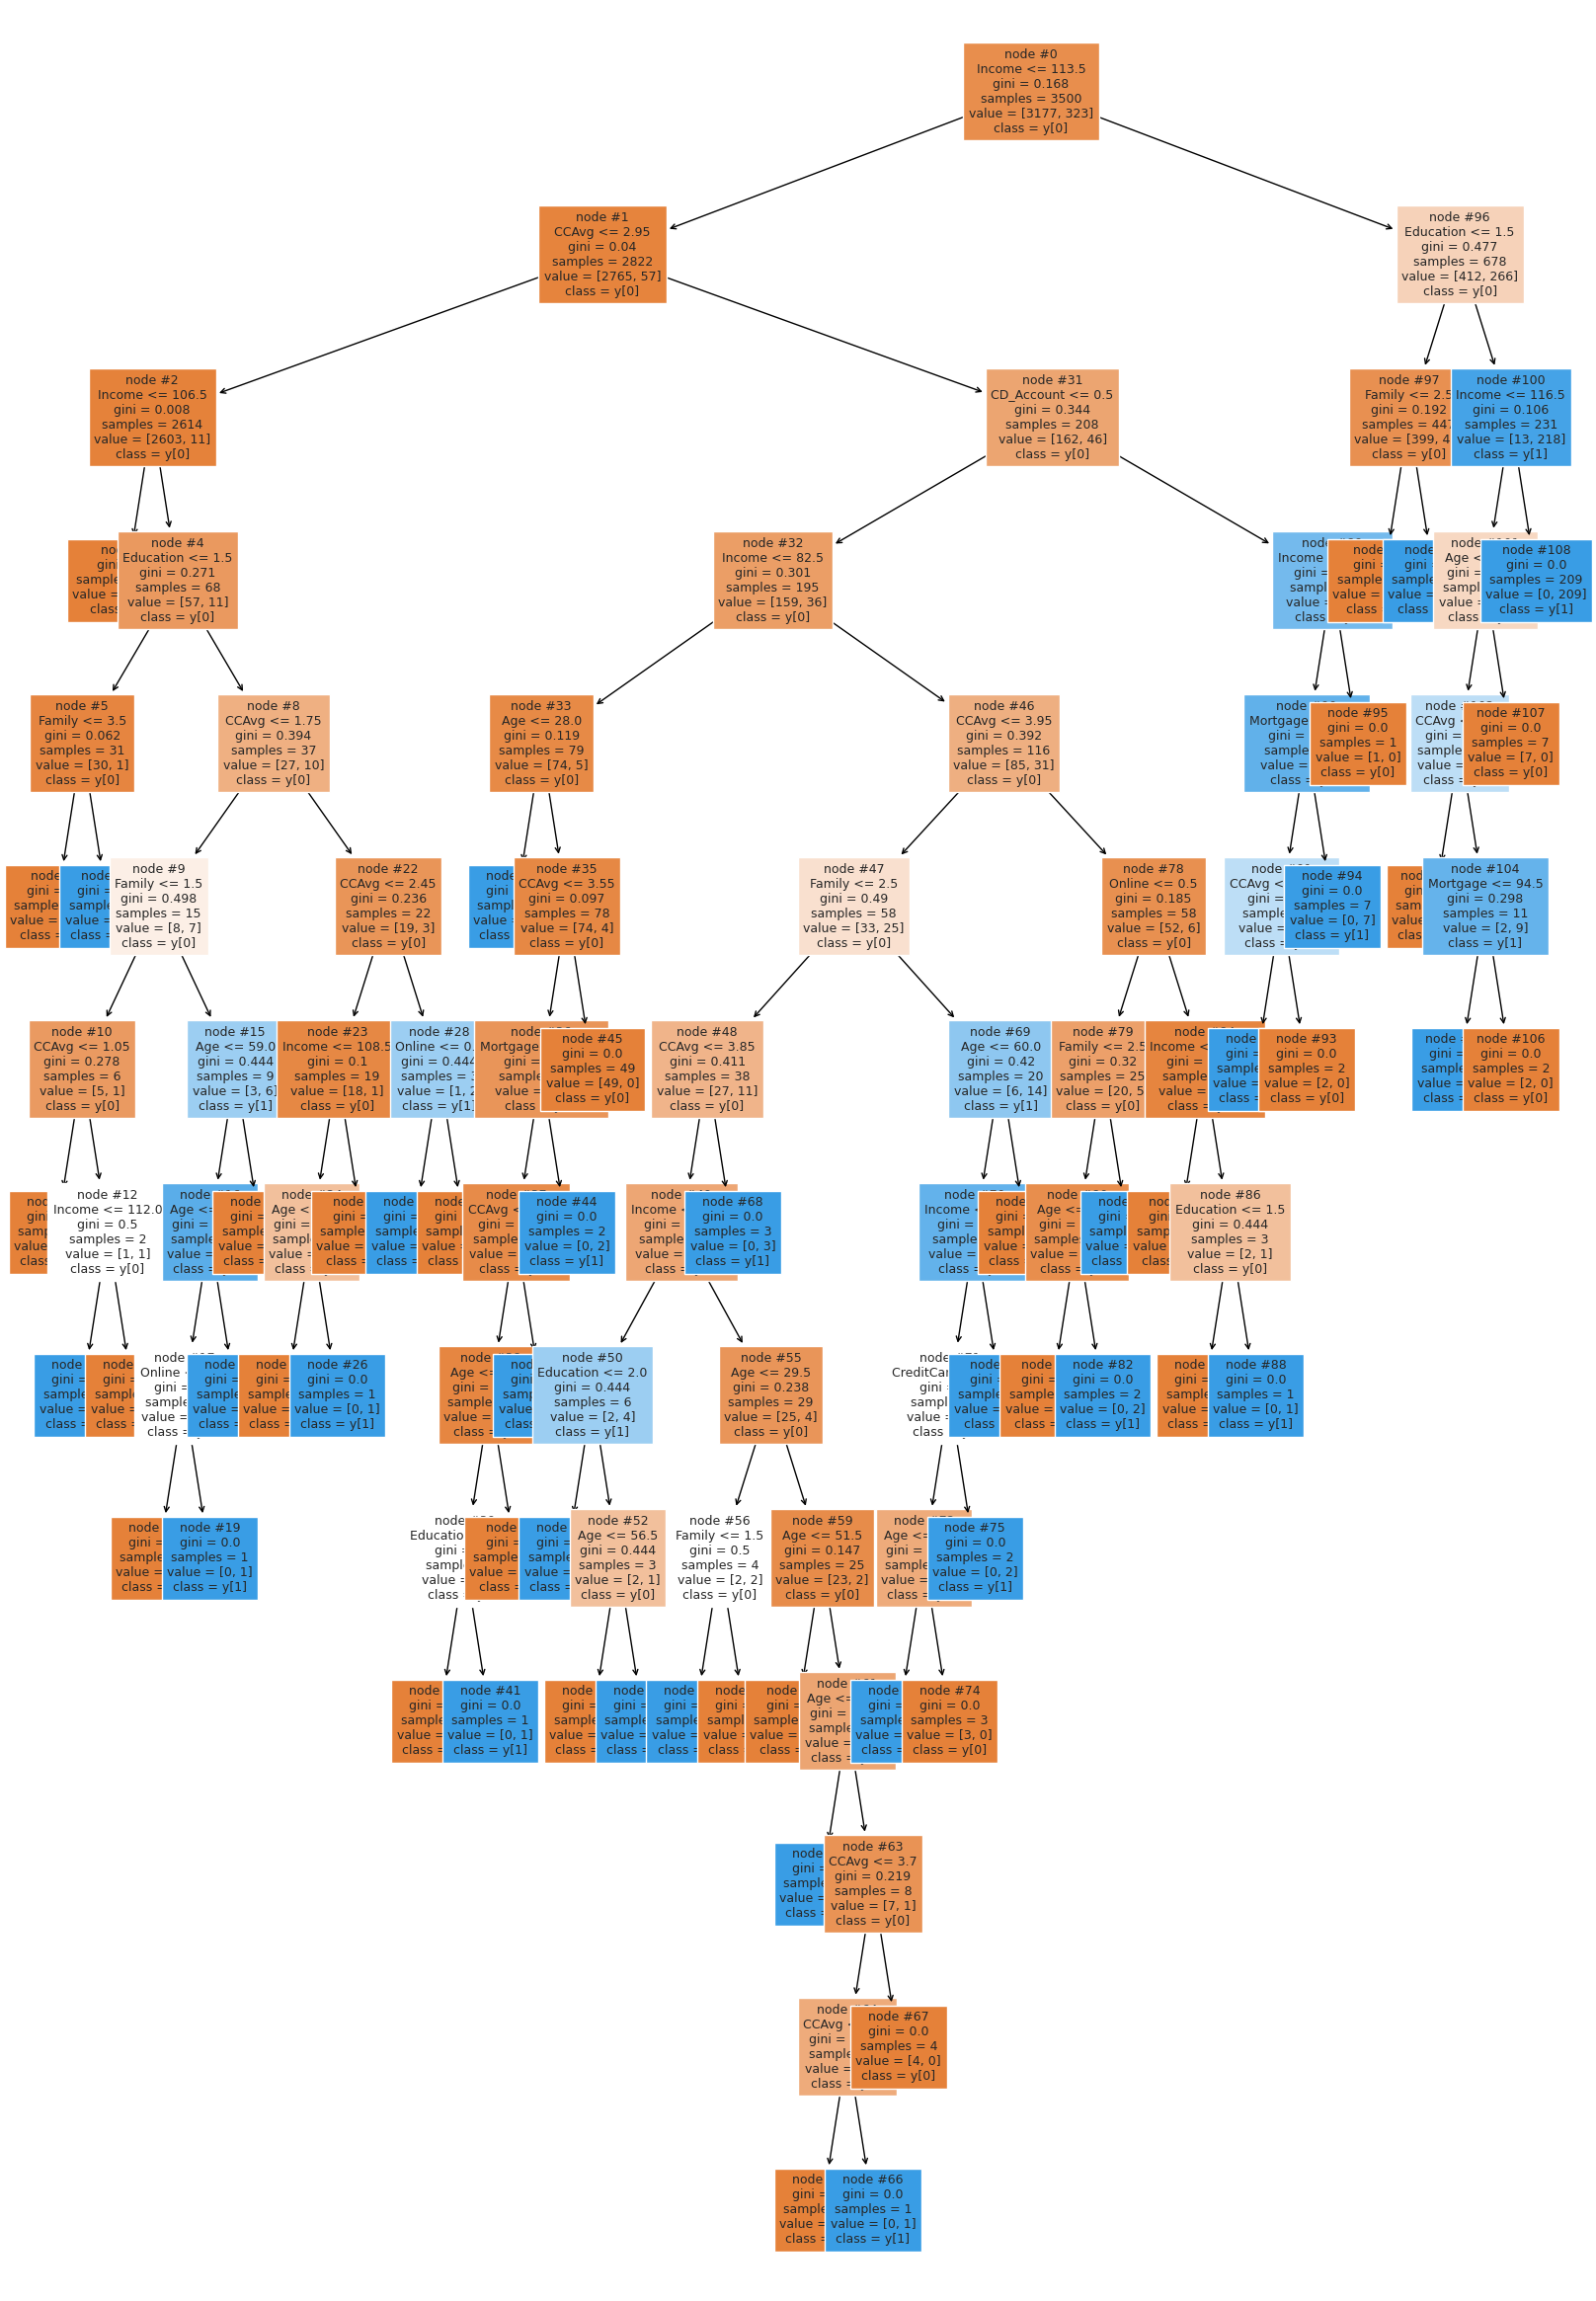

In [67]:
# Visualization of the decision tree
plt.figure(figsize=(20,30))

out = tree.plot_tree(model,feature_names=feature_names,filled=True,fontsize=9,node_ids=True,class_names=True)
for o in out:
     arrow = o.arrow_patch
     if arrow is not None:
        arrow.set_edgecolor('black')
        arrow.set_linewidth(1)
plt.show()

In [68]:
# Text report showing the rules of a decision tree -

print(tree.export_text(model,feature_names=feature_names,show_weights=True))

|--- Income <= 113.50
|   |--- CCAvg <= 2.95
|   |   |--- Income <= 106.50
|   |   |   |--- weights: [2546.00, 0.00] class: 0
|   |   |--- Income >  106.50
|   |   |   |--- Education <= 1.50
|   |   |   |   |--- Family <= 3.50
|   |   |   |   |   |--- weights: [30.00, 0.00] class: 0
|   |   |   |   |--- Family >  3.50
|   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |--- Education >  1.50
|   |   |   |   |--- CCAvg <= 1.75
|   |   |   |   |   |--- Family <= 1.50
|   |   |   |   |   |   |--- CCAvg <= 1.05
|   |   |   |   |   |   |   |--- weights: [4.00, 0.00] class: 0
|   |   |   |   |   |   |--- CCAvg >  1.05
|   |   |   |   |   |   |   |--- Income <= 112.00
|   |   |   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |   |   |--- Income >  112.00
|   |   |   |   |   |   |   |   |--- weights: [1.00, 0.00] class: 0
|   |   |   |   |   |--- Family >  1.50
|   |   |   |   |   |   |--- Age <= 59.00
|   |   |   |   |   |   |   |--- Age <= 33.50


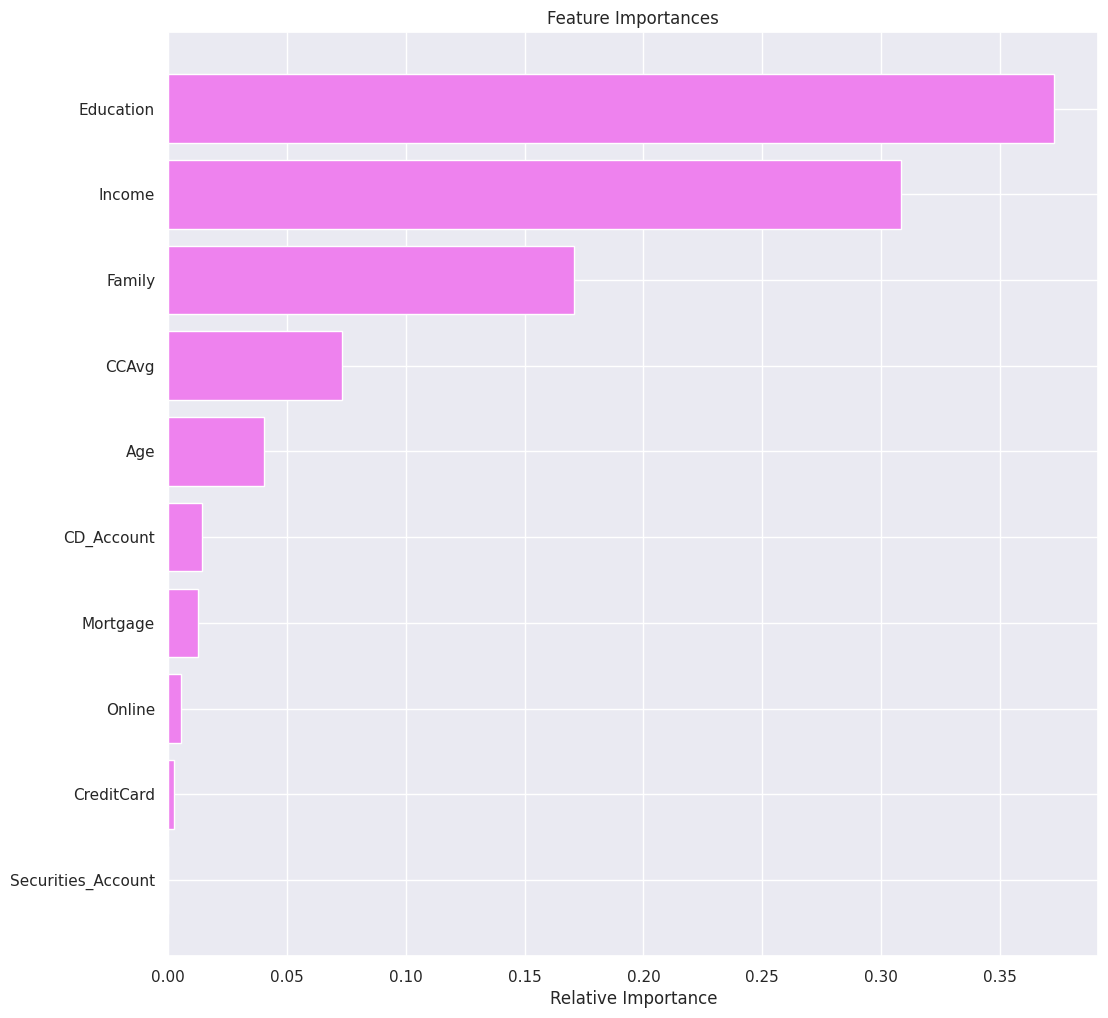

In [69]:
# Visualization of the features importances 
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

Education level, income and family size are the top three important features.

#### Using GridSearch for Hyperparameter tuning of our tree model¶

In [70]:
# Choose the type of classifier. 
estimator = DecisionTreeClassifier(random_state=1)

# Grid of parameters to choose from

parameters = {'max_depth': np.arange(1,10), 
              'min_samples_leaf': [1, 2, 5, 7, 10,15,20],
              'max_leaf_nodes' : [5, 10,15,20,25,30],
              'min_impurity_decrease': [0.0001,0.001,0.01,0.1]
             }

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(estimator, parameters, scoring=acc_scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data. 
estimator.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=9, max_leaf_nodes=30,
                       min_impurity_decrease=0.0001, random_state=1)

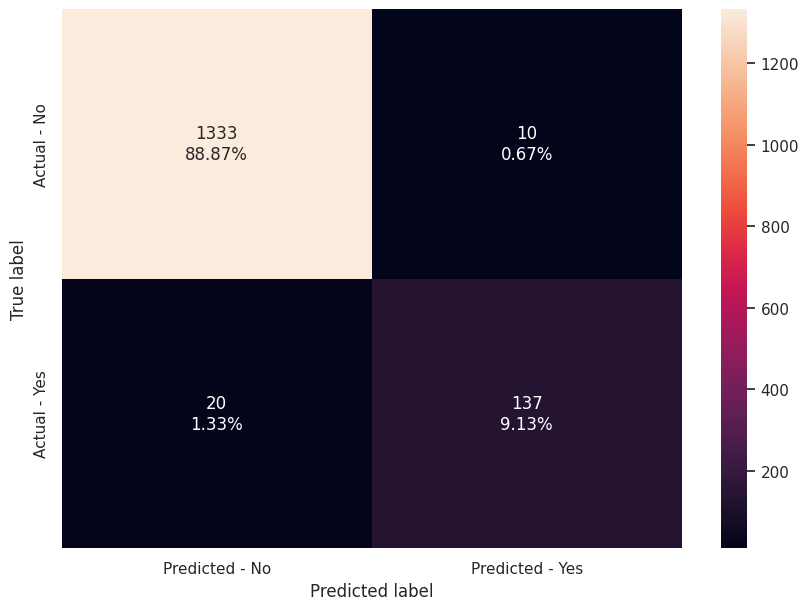

In [71]:
make_confusion_matrix(estimator,y_test)

The confusion matrix:

    True Positives (TP): Correctly predicted 137 customers buying the loan

    True Negatives (TN): Correctly predicted 1333 customers not buying the loan

    False Positives (FP): Incorrectly predicted 10 customers buying the loan (type error I)

    False Negatives (FN): Incorrectly predicted 20 customers not buying the loan (type error II)



In [72]:
get_recall_score(estimator)

Recall on training set :  0.9380804953560371
Recall on test set :  0.8726114649681529


In [73]:
# Check misclassification error
print("Misclassification on training set : ", 1-estimator.score(X_train, y_train))
print("Misclassification on test set : ", 1-estimator.score(X_test, y_test))

Misclassification on training set :  0.006285714285714339
Misclassification on test set :  0.020000000000000018


In [74]:
column_names = list(X.columns)
feature_names = column_names
print(feature_names)

['Age', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard']


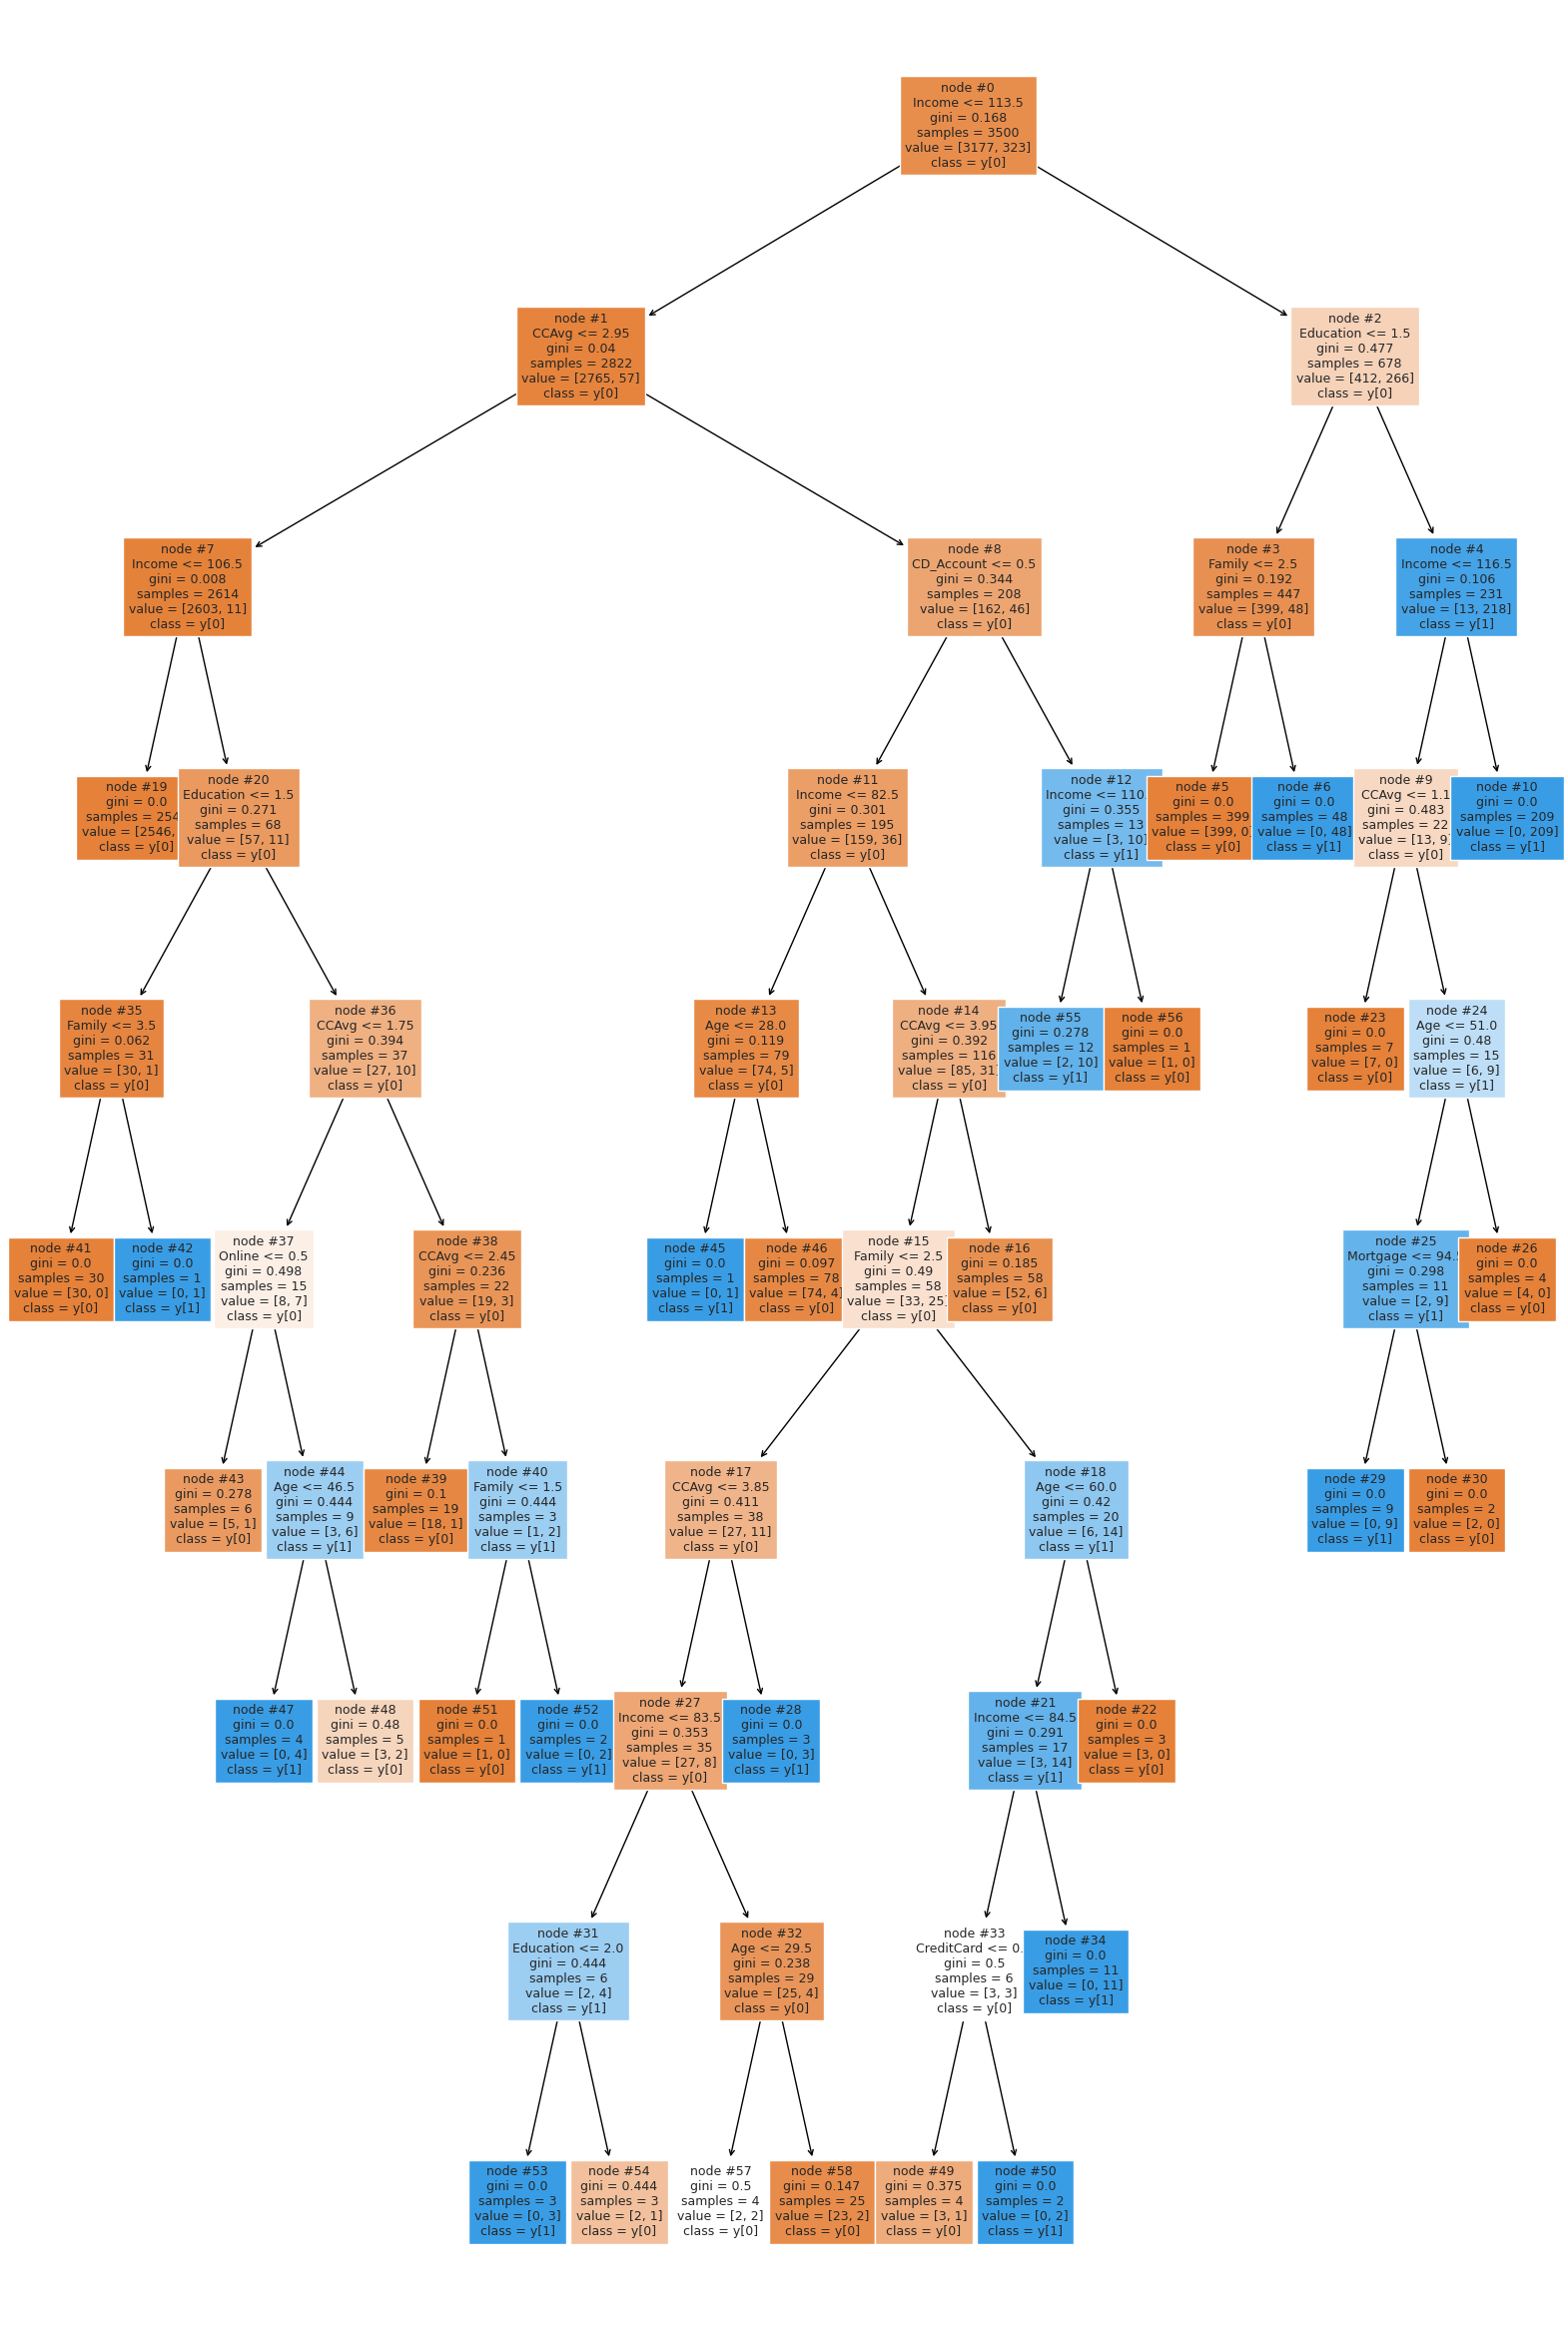

In [75]:
plt.figure(figsize=(20,30))

out = tree.plot_tree(estimator,feature_names=feature_names,filled=True,fontsize=9,node_ids=True,class_names=True)
for o in out:
     arrow = o.arrow_patch
     if arrow is not None:
        arrow.set_edgecolor('black')
        arrow.set_linewidth(1)
plt.show()

### Cost Complexity Pruning

In [76]:
# Now let's build a model using cost complexity pruning
clf = DecisionTreeClassifier(random_state=1)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [77]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000,0.000000
1,0.000238,0.000476
2,0.000245,0.000966
3,0.000250,0.001466
4,0.000271,0.002007
5,0.000275,0.002557
6,0.000276,0.003108
7,0.000277,0.003662
8,0.000381,0.004043
9,0.000381,0.004805


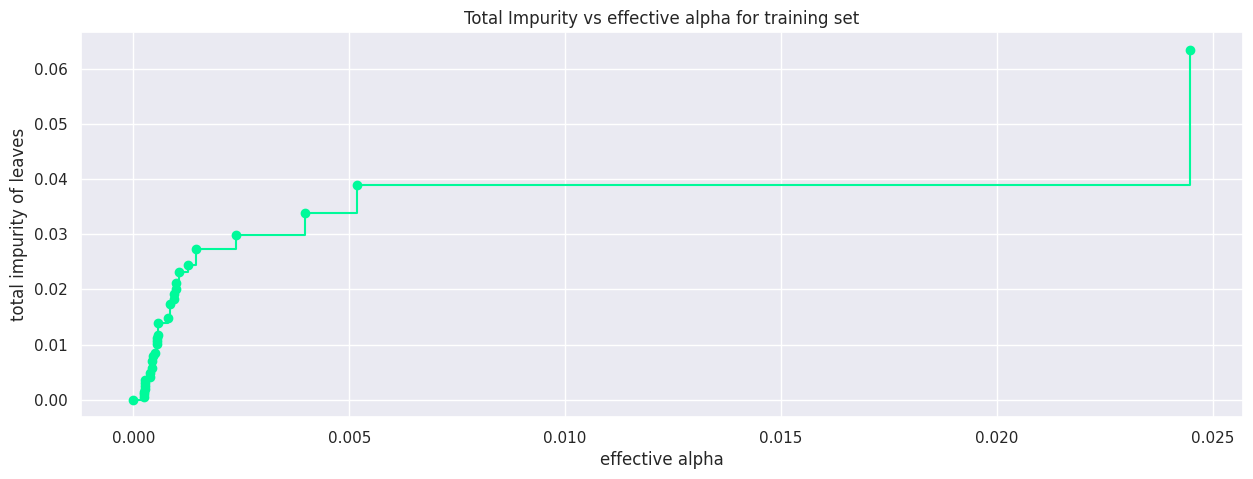

In [78]:
fig, ax = plt.subplots(figsize=(15,5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker='o', drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

In [79]:
# Now we train a decision tree using the effective alphas
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=1, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)
print("Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
      clfs[-1].tree_.node_count, ccp_alphas[-1]))

Number of nodes in the last tree is: 1 with ccp_alpha: 0.05206542558865251


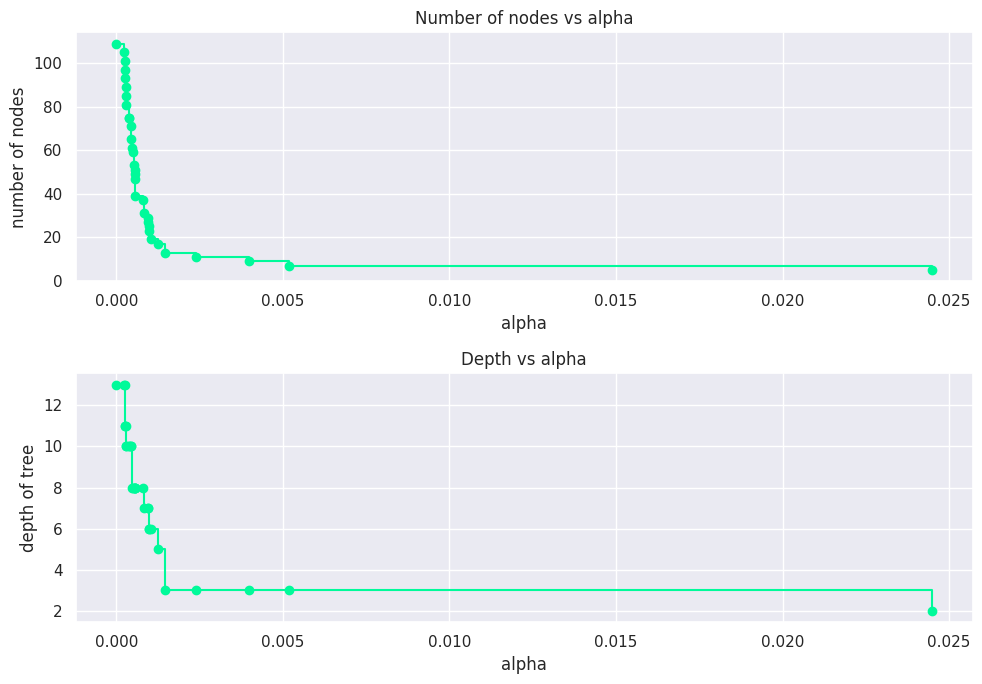

In [80]:
# Now we remove the last element in clfs and ccp_alphas
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1,figsize=(10,7))
ax[0].plot(ccp_alphas, node_counts, marker='o', drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker='o', drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

### Recall vs alpha for training and testing sets

In [81]:
recall_train=[]
for clf in clfs:
    pred_train3=clf.predict(X_train)
    values_train=metrics.recall_score(y_train,pred_train3)
    recall_train.append(values_train)

In [82]:
recall_test=[]
for clf in clfs:
    pred_test3=clf.predict(X_test)
    values_test=metrics.recall_score(y_test,pred_test3)
    recall_test.append(values_test)

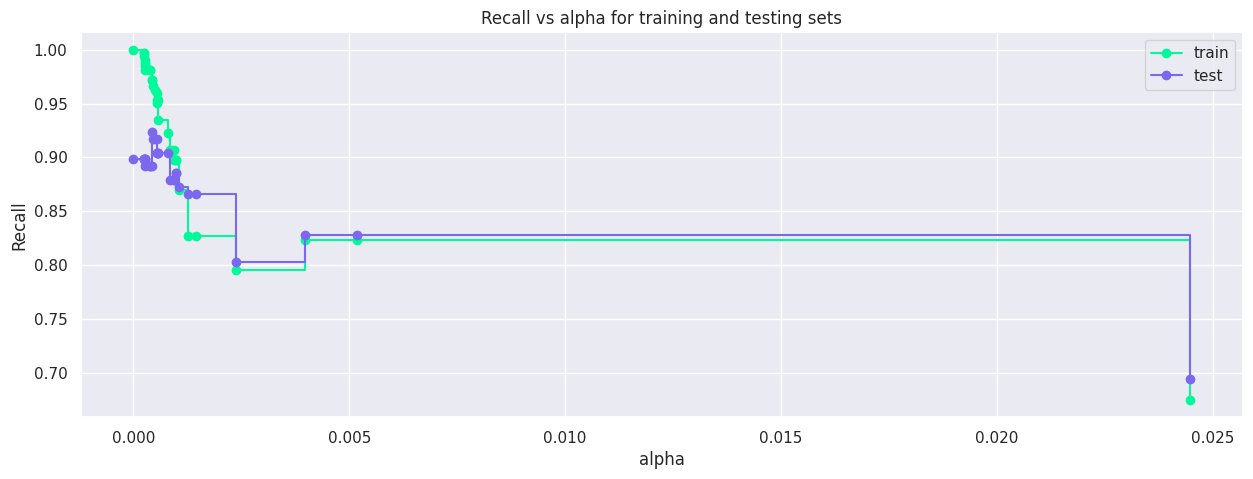

In [83]:
fig, ax = plt.subplots(figsize=(15,5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(ccp_alphas, recall_train, marker='o', label="train",
        drawstyle="steps-post")
ax.plot(ccp_alphas, recall_test, marker='o', label="test",
        drawstyle="steps-post")
ax.legend()
plt.show()

In [84]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=0.0004395604395604396, random_state=1)


In [85]:
get_recall_score(best_model)

Recall on training set :  0.9721362229102167
Recall on test set :  0.9235668789808917


In [86]:
# Check misclassification error
print("Misclassification on training set : ", 1-best_model.score(X_train, y_train))
print("Misclassification on test set : ", 1-best_model.score(X_test, y_test))

Misclassification on training set :  0.00457142857142856
Misclassification on test set :  0.01666666666666672


With post-pruning we get the highest recall test set.

#### Confusion Matrix 

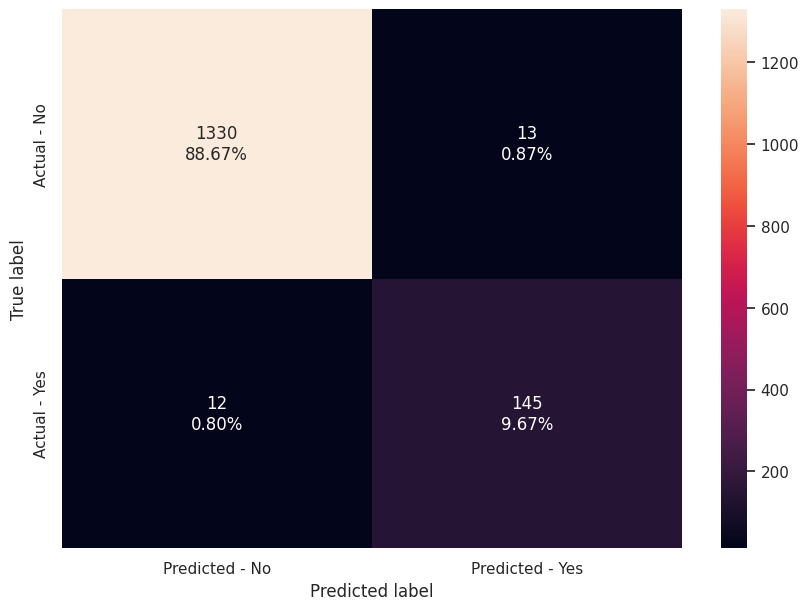

In [87]:
make_confusion_matrix(best_model,y_test)

The confusion matrix:

- True Positives (TP): 
    Correctly predicted 145 customers buying the loan
        
- True Negatives (TN): 
    Correctly predicted 1330 customers not buying the loan
       
- False Positives (FP): 
    Incorrectly predicted 13 customers buying the loan (type error I)
   
- False Negatives (FN): 
    Incorrectly predicted 12 customers not buying the loan (type error II)

In [88]:
# Let's check again the importance of features in the tree building

print (pd.DataFrame(best_model.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

                         Imp
Education           0.382531
Income              0.315692
Family              0.178320
CCAvg               0.067533
Age                 0.028136
CD_Account          0.014825
Mortgage            0.011506
Online              0.001458
Securities_Account  0.000000
CreditCard          0.000000


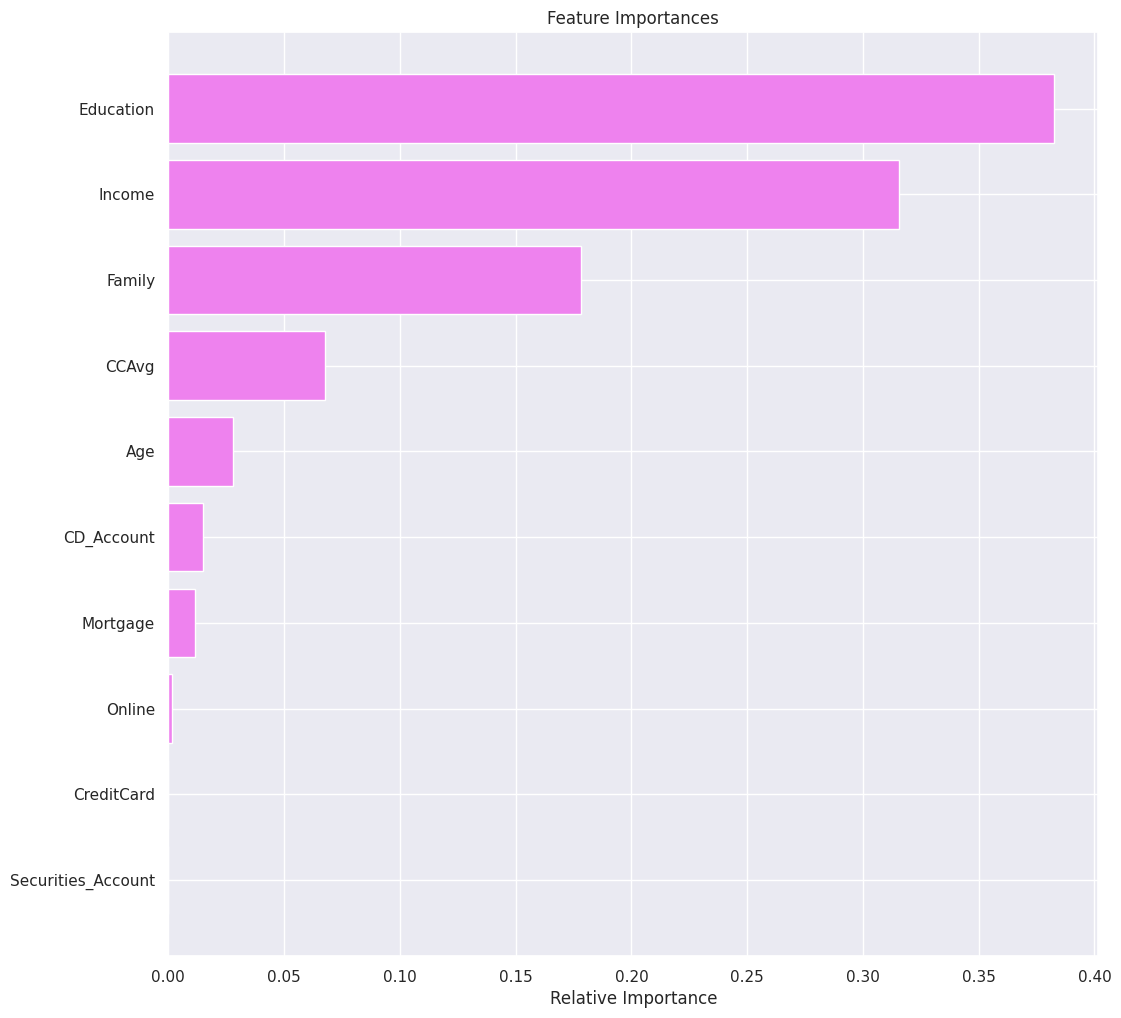

In [89]:
# Visualization of the features importances in the best model
importances = best_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

Education level, income and family size are the top three important features as shown previously.

### Compare decision tree and logistic regression

In [90]:
# Now let's compare all the models
comparison_frame = pd.DataFrame({'Model':['Logistic Regression','Initial decision tree model','Decision treee with hyperparameter tuning',
                                         'Decision tree with post-pruning'], 'Train_Recall':[0.74,1,0.94,0.97], 'Test_Recall':[0.80,0.90,0.87,0.92]}) 
comparison_frame

,Model,Train_Recall,Test_Recall
0,Logistic Regression,0.74,0.80
1,Initial decision tree model,1.00,0.90
2,Decision treee with hyperparameter tuning,0.94,0.87
3,Decision tree with post-pruning,0.97,0.92


In [91]:
# Now let's compare the missclassification model on the three models
comparison_frame = pd.DataFrame({'Model':['Logistic Regression','Initial decision tree model','Decision treee with hyperparameter tuning',
                                         'Decision tree with post-pruning'],'train_misclassification':[0.09,0,0.006,0.005],'test_misclassification':[0.09,0.019,0.02,0.016]}) 
comparison_frame

,Model,train_misclassification,test_misclassification
0,Logistic Regression,0.090,0.090
1,Initial decision tree model,0.000,0.019
2,Decision treee with hyperparameter tuning,0.006,0.020
3,Decision tree with post-pruning,0.005,0.016


Decision tree with post-pruning is giving the best recall score.
Decision tree with post-pruning is giving the smallest misclassification rate.